# NLP Final — Workplace Media Analysis

**Dataset:** `mediacloud_articles_clean.csv`  
**Goal:** Compare how news outlets frame five major topics (AI, Climate, Economy, Immigration, Iran) using lexical, sentiment, and moral-values analyses.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **Setup** | Imports, data load, deduplication, text field normalization |
| **Part 1** | Cross-outlet comparison within each topic (top terms, TF-IDF, sentiment, heatmap) |
| **Part 2** | Per-outlet analysis across all topics (top terms, sentiment, divergence charts) |
| **Part 3** | Per-topic NMF sub-theme extraction with labeled outlet proportions |
| **Part 4** | Compact TF-IDF reporting matrices + full Excel export |
| **Part 5** | Moral Foundations Theory (MFT) scoring by outlet and by topic |


## Setup

Install dependencies (uncomment if needed), then import all libraries and load the dataset.

In [1]:
#pip install seaborn

In [2]:
# Uncomment to install if needed:
# !pip install nltk numpy scikit-learn

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('wordnet')


from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

DATA_PATH = 'mediacloud_articles_clean.csv'
print('Setup complete')


Setup complete


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\woodj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Data Loading & Cleaning

Load the CSV, deduplicate by URL, standardize column names, and filter to rows that have at least one text field and a valid topic label.

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()


,topic,keyword,source_name,source_id,title,url,publish_date,language,full_text,title_scraped,text_length
0,AI,artificial intelligence,AP,106145,Low-voltage utility elections face surge of at...,https://apnews.com/article/energy-politics-ele...,2026-04-06,en,Low-voltage utility elections face surge of at...,Low-voltage utility elections face surge of at...,7164
1,AI,artificial intelligence,AP,106145,Wall Street's 2025 bonuses reached unprecedent...,https://apnews.com/article/wall-street-bonuses...,2026-03-26,en,Wall Streets 2025 bonuses reached unprecedente...,Wall Street's 2025 bonuses reached unprecedent...,2269
2,AI,artificial intelligence,AP,106145,Michigan license plate cameras face backlash: ...,https://apnews.com/article/privacy-michigan-ge...,2026-02-02,en,Michigan license plate cameras face backlash: ...,Michigan license plate cameras face backlash: ...,9474
3,AI,artificial intelligence,AP,106145,China's Alibaba targets $100B in AI and cloud ...,https://apnews.com/article/china-alibaba-earni...,2026-03-19,en,Chinas Alibaba targets $100B in AI and cloud r...,China's Alibaba targets $100B in AI and cloud ...,2454
4,AI,artificial intelligence,AP,106145,Nevada unveils new statewide data classificati...,https://apnews.com/article/nevada-government-p...,2026-02-11,en,Nevada unveils new statewide data classificati...,Nevada unveils new statewide data classificati...,3666


In [4]:
# Deduplicate by URL
if 'url' in df.columns:
    df = df.drop_duplicates(subset=['url'], keep='last')
df = df.reset_index(drop=True)

# Standardize outlet/source column name
if 'source_name' in df.columns:
    df['outlet'] = df['source_name'].astype(str)
elif 'outlet' in df.columns:
    df['outlet'] = df['outlet'].astype(str)
else:
    df['outlet'] = 'Unknown'

# Separate headline and body text
if 'title_scraped' in df.columns:
    headline_source = df['title_scraped']
elif 'title' in df.columns:
    headline_source = df['title']
else:
    headline_source = pd.Series([''] * len(df), index=df.index)

df['headline_text'] = headline_source.astype(str).fillna('').str.strip()
df['article_text']  = df.get('full_text', pd.Series([''] * len(df), index=df.index)).astype(str).fillna('').str.strip()

# Keep rows with at least one text field and a valid topic label
df = df[(df['headline_text'].str.len() > 0) | (df['article_text'].str.len() > 0)].copy()
df = df[df['topic'].notna()].copy()
df['topic'] = df['topic'].astype(str).str.strip()

print('Rows in full df:', len(df))
print('Topics:', sorted(df['topic'].unique()))
df.head()


Rows in full df: 2334
Topics: ['AI', 'Climate', 'Economy', 'Immigration', 'Iran']


,topic,keyword,source_name,source_id,title,url,publish_date,language,full_text,title_scraped,text_length,outlet,headline_text,article_text
0,AI,artificial intelligence,AP,106145,Low-voltage utility elections face surge of at...,https://apnews.com/article/energy-politics-ele...,2026-04-06,en,Low-voltage utility elections face surge of at...,Low-voltage utility elections face surge of at...,7164,AP,Low-voltage utility elections face surge of at...,Low-voltage utility elections face surge of at...
1,AI,artificial intelligence,AP,106145,Wall Street's 2025 bonuses reached unprecedent...,https://apnews.com/article/wall-street-bonuses...,2026-03-26,en,Wall Streets 2025 bonuses reached unprecedente...,Wall Street's 2025 bonuses reached unprecedent...,2269,AP,Wall Street's 2025 bonuses reached unprecedent...,Wall Streets 2025 bonuses reached unprecedente...
2,AI,artificial intelligence,AP,106145,Michigan license plate cameras face backlash: ...,https://apnews.com/article/privacy-michigan-ge...,2026-02-02,en,Michigan license plate cameras face backlash: ...,Michigan license plate cameras face backlash: ...,9474,AP,Michigan license plate cameras face backlash: ...,Michigan license plate cameras face backlash: ...
3,AI,artificial intelligence,AP,106145,China's Alibaba targets $100B in AI and cloud ...,https://apnews.com/article/china-alibaba-earni...,2026-03-19,en,Chinas Alibaba targets $100B in AI and cloud r...,China's Alibaba targets $100B in AI and cloud ...,2454,AP,China's Alibaba targets $100B in AI and cloud ...,Chinas Alibaba targets $100B in AI and cloud r...
4,AI,artificial intelligence,AP,106145,Nevada unveils new statewide data classificati...,https://apnews.com/article/nevada-government-p...,2026-02-11,en,Nevada unveils new statewide data classificati...,Nevada unveils new statewide data classificati...,3666,AP,Nevada unveils new statewide data classificati...,Nevada unveils new statewide data classificati...


### Helper Functions

Shared utilities used across all analysis sections.

In [5]:
def normalize_document(doc):
    """Basic tokenization: lowercase, alpha-only, remove stopwords."""
    doc = str(doc).lower()
    tokens = word_tokenize(doc)
    return ' '.join(t for t in tokens if t.isalpha() and t not in stop_words)


def top_terms_for_docs(docs, top_n=10):
    """Return top N terms by TF-IDF (with raw count) for a list of documents."""
    docs = [d for d in docs if isinstance(d, str) and d.strip()]
    if not docs:
        return pd.DataFrame(columns=['term', 'count', 'tfidf'])

    cv = CountVectorizer(ngram_range=(1, 1), min_df=1)
    cv_matrix = cv.fit_transform(docs)
    count_scores = np.asarray(cv_matrix.sum(axis=0)).ravel()
    terms = cv.get_feature_names_out()

    tfidf = TfidfVectorizer(min_df=2, use_idf=True)
    tfidf_matrix = tfidf.fit_transform(docs)
    tfidf_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
    tfidf_terms = tfidf.get_feature_names_out()

    tfidf_lookup = pd.Series(tfidf_scores, index=tfidf_terms)
    out = pd.DataFrame({'term': terms, 'count': count_scores})
    out['tfidf'] = out['term'].map(tfidf_lookup).fillna(0.0)
    return out.sort_values(['tfidf', 'count'], ascending=False).head(top_n).reset_index(drop=True)


def outlet_sentiment(df_in, text_col):
    """Compute average VADER sentiment scores by outlet for a given text column."""
    scores = df_in[text_col].fillna('').apply(lambda x: sia.polarity_scores(str(x)))
    score_df = pd.DataFrame(scores.tolist())
    score_df.insert(0, 'outlet', df_in['outlet'].values)
    return (
        score_df.groupby('outlet', as_index=False)[['compound', 'pos', 'neu', 'neg']]
        .mean()
        .sort_values('compound', ascending=False)
    )


### Topic-Specific Noise Word Detection

Auto-detect words that appear across all outlets within a topic. these are likely topic-level stop words. The result is merged with a manual base list and global news noise to build the final blocklist used throughout the analysis.

**Three blocklist layers:**
- `manual_topic_noise_base` — obvious topic labels (ai, climate, economy, etc.)
- `global_news_noise` — generic media words (said, news, video, cnn, etc.)
- `manual_topic_noise_auto` — auto-detected shared words per topic (words common across all outlets)

Cleaned text is saved to `article_text_topic_clean` and `headline_text_topic_clean`.

In [6]:
AUTO_TEXT_COL       = 'article_text'
MIN_OUTLET_COVERAGE = 1.0   # must appear in all outlets for a topic
MIN_TOTAL_COUNT     = 12    # minimum total occurrences inside a topic
TOP_K_PER_TOPIC     = 40    # max overlapping terms removed per topic

def _simple_alpha_tokens(text):
    return re.findall(r'[a-z]+', str(text).lower())

manual_topic_noise_auto = {}

for topic_name, g_topic in df.groupby('topic'):
    outlet_values = sorted(g_topic['outlet'].dropna().unique())
    n_outlets = len(outlet_values)
    if n_outlets == 0:
        continue

    total_counter  = Counter()
    outlet_presence = defaultdict(int)

    for _, g_outlet in g_topic.groupby('outlet'):
        outlet_counter = Counter()
        for txt in g_outlet[AUTO_TEXT_COL].fillna(''):
            outlet_counter.update(_simple_alpha_tokens(txt))
        total_counter.update(outlet_counter)
        for tok in outlet_counter:
            outlet_presence[tok] += 1

    candidates = [
        (tok, cnt, outlet_presence[tok] / n_outlets)
        for tok, cnt in total_counter.items()
        if outlet_presence[tok] / n_outlets >= MIN_OUTLET_COVERAGE and cnt >= MIN_TOTAL_COUNT
    ]
    candidates = sorted(candidates, key=lambda x: (-x[1], -x[2], x[0]))[:TOP_K_PER_TOPIC]
    manual_topic_noise_auto[str(topic_name)] = {w for w, _, _ in candidates}

preview = {t: sorted(list(words))[:15] for t, words in manual_topic_noise_auto.items()}
preview


{'AI': ['a',
  'about',
  'ai',
  'an',
  'and',
  'are',
  'as',
  'at',
  'be',
  'but',
  'by',
  'for',
  'from',
  'has',
  'have'],
 'Climate': ['a',
  'about',
  'an',
  'and',
  'are',
  'as',
  'at',
  'be',
  'but',
  'by',
  'climate',
  'for',
  'from',
  'has',
  'have'],
 'Economy': ['a',
  'about',
  'an',
  'and',
  'are',
  'as',
  'at',
  'be',
  'but',
  'by',
  'for',
  'from',
  'has',
  'have',
  'he'],
 'Immigration': ['a',
  'an',
  'and',
  'are',
  'as',
  'at',
  'be',
  'been',
  'but',
  'by',
  'federal',
  'for',
  'from',
  'has',
  'have'],
 'Iran': ['a',
  'an',
  'and',
  'are',
  'as',
  'at',
  'be',
  'been',
  'but',
  'by',
  'for',
  'from',
  'has',
  'have',
  'he']}

In [57]:
# Manual base list: obvious topic label tokens
manual_topic_noise_base = {
    'AI':          {'ai', 'artificial', 'intelligence'},
    'Climate':     {'climate'},
    'Economy':     {'economy', 'economic'},
    'Immigration': {'immigration', 'immigrant', 'immigrants', 'migrant', 'migrants'},
    'Iran':        {'iran', 'iranian', 'us', 'united', 'states'},
}

# Generic news noise
global_news_noise = {
    'said', 'says', 'new', 'one', 'two', 'year', 'years', 'could', 'would', 'also', 'get',
    'us', 'u', 's', 'mr', 'ms',
    'cnn', 'bbc', 'ap', 'fox', 'news', 'newsmax', 'business', 'politics',
    'ad', 'ads', 'video', 'watch', 'live', 'documentaries', 'feedback',
    'click', 'app', 'apps', 'digital', 'download',  # Fox app-promo
    'rights', 'reserved',                            # copyright footers
    'cnns', 'foxs', 'bbcs', 'aps', 'newsmaxs',       # outlet possessives
}

# Merge manual base + auto-detected per topic
manual_topic_noise = {}
all_topic_keys = set(manual_topic_noise_base.keys()) | set(manual_topic_noise_auto.keys())
for key in all_topic_keys:
    manual_topic_noise[key] = (
        set(manual_topic_noise_base.get(key, set()))
        | set(manual_topic_noise_auto.get(key, set()))
    )

def tokenize_alpha(text):
    return re.findall(r'[a-z]+', str(text).lower())

def build_topic_blocklist(topic_value, keyword_value):
    return (
        set(tokenize_alpha(topic_value))
        | set(tokenize_alpha(keyword_value))
        | manual_topic_noise.get(str(topic_value), set())
    )

def normalize_topic_clean(text, topic_value, keyword_value):
    tokens   = word_tokenize(str(text).lower())
    blocklist = stop_words | global_news_noise | build_topic_blocklist(topic_value, keyword_value)
    return ' '.join(t for t in tokens if t.isalpha() and t not in blocklist)

df['article_text_topic_clean'] = df.apply(
    lambda r: normalize_topic_clean(r['article_text'],  r.get('topic', ''), r.get('keyword', '')), axis=1
)
df['headline_text_topic_clean'] = df.apply(
    lambda r: normalize_topic_clean(r['headline_text'], r.get('topic', ''), r.get('keyword', '')), axis=1
)

print('Merged noise dictionary preview (first 15 terms/topic):')
for t in sorted(manual_topic_noise):
    print(t, '->', sorted(list(manual_topic_noise[t]))[:15])

df[['topic', 'keyword', 'article_text_topic_clean', 'headline_text_topic_clean']].head()


Merged noise dictionary preview (first 15 terms/topic):
AI -> ['a', 'about', 'ai', 'an', 'and', 'are', 'artificial', 'as', 'at', 'be', 'but', 'by', 'for', 'from', 'has']
Climate -> ['a', 'about', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by', 'climate', 'for', 'from', 'has', 'have']
Economy -> ['a', 'about', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by', 'economic', 'economy', 'for', 'from', 'has']
Immigration -> ['a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'but', 'by', 'federal', 'for', 'from', 'has', 'have']
Iran -> ['a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'but', 'by', 'for', 'from', 'has', 'have', 'he']


topic                  keyword  \
0    AI  artificial intelligence   
1    AI  artificial intelligence   
2    AI  artificial intelligence   
3    AI  artificial intelligence   
4    AI  artificial intelligence   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

> **Note:** All analyses from this point forward use `article_text_topic_clean` and `headline_text_topic_clean`.

---
## Part 1: Cross-Outlet Comparison Within Each Topic

For every topic, compare outlets on:
- Top terms by count and TF-IDF (body and headline)
- Average VADER sentiment by outlet


In [58]:
topics = sorted(df['topic'].dropna().unique())

TOP_TERMS_PER_OUTLET  = 40
TOP_TERMS_FOR_SUMMARY = 20

topic_outlet_top_terms        = []
topic_outlet_sentiment_tables = {}

for topic in topics:
    topic_df = df[df['topic'] == topic].copy()
    topic_df['norm_article_text']   = topic_df['article_text_topic_clean'].astype(str)
    topic_df['norm_headline_text']  = topic_df['headline_text_topic_clean'].astype(str)

    print(f"\n{'='*80}\nTOPIC: {topic} | rows: {len(topic_df)}\n{'='*80}")

    for outlet in sorted(topic_df['outlet'].unique()):
        outlet_df  = topic_df[topic_df['outlet'] == outlet].copy()
        body_terms = top_terms_for_docs(outlet_df['norm_article_text'].tolist(),  top_n=TOP_TERMS_PER_OUTLET)
        head_terms = top_terms_for_docs(outlet_df['norm_headline_text'].tolist(), top_n=TOP_TERMS_PER_OUTLET)

        topic_outlet_top_terms.append({
            'topic':              topic,
            'outlet':             outlet,
            'n_articles':         len(outlet_df),
            'top_body_terms':     ', '.join(body_terms['term'].head(TOP_TERMS_FOR_SUMMARY).tolist()),
            'top_headline_terms': ', '.join(head_terms['term'].head(TOP_TERMS_FOR_SUMMARY).tolist()),
        })

        print(f"\nOutlet: {outlet} | n_articles: {len(outlet_df)}")
        print('Top BODY terms (TF-IDF-ranked):');    display(body_terms)
        print('Top HEADLINE terms (TF-IDF-ranked):'); display(head_terms)

    sentiment_body = outlet_sentiment(topic_df, 'article_text')
    sentiment_head = outlet_sentiment(topic_df, 'headline_text')
    topic_outlet_sentiment_tables[topic] = {'body': sentiment_body, 'headline': sentiment_head}

    print('Sentiment by outlet (BODY)');    display(sentiment_body)
    print('Sentiment by outlet (HEADLINE)'); display(sentiment_head)



TOPIC: AI | rows: 458

Outlet: AP | n_articles: 86
Top BODY terms (TF-IDF-ranked):


,term,count,tfidf
0,data,147,2.609286
1,billion,107,2.545370
2,people,172,2.454376
3,last,193,2.255202
4,company,101,2.136309
5,oil,71,1.973032
6,power,102,1.943244
7,market,76,1.936538
8,health,80,1.918032
9,president,189,1.895989


Top HEADLINE terms (TF-IDF-ranked):


,term,count,tfidf
0,deal,6,2.831172
1,street,4,2.532387
2,wall,4,2.532387
3,big,5,2.516187
4,world,3,2.482691
5,plans,5,2.448618
6,war,5,2.295838
7,tech,3,2.230930
8,use,4,2.205619
9,google,3,2.135931



Outlet: BBC | n_articles: 73
Top BODY terms (TF-IDF-ranked):


...

,term,count,tfidf
0,oil,10,4.876141
1,prices,8,4.331470
2,conflict,6,3.925537
3,israel,8,3.532424
4,strike,4,2.956587
5,deal,5,2.940253
6,talks,5,2.795371
7,cut,4,2.745892
8,energy,6,2.699701
9,hormuz,5,2.674893


Sentiment by outlet (BODY)


,outlet,compound,pos,neu,neg
1,BBC,-0.284078,0.075783,0.829850,0.094333
3,Fox News,-0.414937,0.087720,0.797810,0.114440
4,Newsmax,-0.425299,0.073870,0.817110,0.109020
2,CNN,-0.451576,0.073170,0.823110,0.103780
0,AP,-0.493762,0.074404,0.816202,0.109414


Sentiment by outlet (HEADLINE)


,outlet,compound,pos,neu,neg
1,BBC,-0.115295,0.097067,0.741283,0.161700
2,CNN,-0.174543,0.049970,0.825580,0.124440
3,Fox News,-0.226641,0.085490,0.721850,0.192690
4,Newsmax,-0.228060,0.054420,0.753630,0.192000
0,AP,-0.308485,0.056939,0.755586,0.187485


#### Part 1 Summary Table — Topic × Outlet Top Terms

In [59]:
topic_outlet_summary = pd.DataFrame(topic_outlet_top_terms)
topic_outlet_summary.sort_values(['topic', 'outlet']).reset_index(drop=True)


,topic,outlet,n_articles,top_body_terms,top_headline_terms
0,AI,AP,86,"data, billion, people, last, company, oil, power, market, health, president, state, energy, growth, companies, war, like, economy, use, google, jobs","deal, street, wall, big, world, plans, war, tech, use, google, stocks, amazon, billion, chatbot, oil, prices, economic, iran, online, parliament"
1,AI,BBC,73,"arts, audio, sport, america, culture, technology, earth, travel, health, home, ireland, australia, wales, africa, scotland, asia, east, middle, europe, uk","first, uk, hull, footage, media, social, explained, fan, help, shooting, west, centre, echo, shows, gets, inside, love, victory, project, making"
2,AI,CNN,99,"gout, war, iran, ice, videos, company, people, world, social, reports, source, media, chinese, like, chinas, first, strait, jobs, china, rise","iran, mexico, crisis, public, make, war, tech, help, economy, chinas, warns, archives, shares, companies, minneapolis, calls, epstein, battle, criminal, north"
3,AI,Fox News,100,"data, people, security, free, president, like, energy, american, iran, information, america, state, access, national, time, use, china, first, media, department","global, use, gets, iran, surge, google, president, tech, san, strikes, house, crisis, data, people, robots, first, francisco, across, crypto, david"
4,AI,Newsmax,100,"anthropic, billion, company, inflation, pentagon, fed, oil, prices, technology, market, nvidia, rate, war, companies, amazon, data, iran, china, openai, investors","fed, tech, anthropic, amazon, oil, fears, iran, openai, investment, china, meta, poll, nvidia, war, ceo, pentagon, market, funds, stocks, house"
5,Climate,AP,99,"water, state, energy, environmental, people, federal, president, winter, health, oil, wind, change, administration, like, last, first, epa, states, power, heat","amazon, olympic, hawaii, administration, brazil, epa, world, water, heat, show, security, aid, launches, wildfires, environmental, vermont, sharks, rules, free, researchers"
6,Climate,BBC,99,"people, water, energy, council, uk, gas, weather, species, oil, government, first, last, scottish, world, scotland, snow, make, sea, wales, like","uk, weather, people, south, national, scottish, amid, farm, west, north, council, farms, flood, world, yorkshire, ni, city, bill, centre, sighting"
7,Climate,CNN,99,"greenland, water, snow, oil, ice, winter, weather, heat, president, people, energy, food, states, change, nio, world, el, arctic, china, security","winter, weather, first, olympics, oil, scientists, greenland, know, snow, february, updates, change, planet, future, western, china, analysis, east, shift, africas"
8,Climate,Fox News,79,"energy, president, california, state, talarico, like, federal, bill, environmental, people, administration, epa, national, told, ice, wrote, states, students, power, funding","ice, california, bill, energy, report, green, biden, warns, la, speech, exposes, trumps, court, groups, lesson, god, dei, winter, claims, greenhouse"
9,Climate,Newsmax,45,"energy, oil, state, gas, people, california, prices, nuclear, power, finding, democrats, europe, epa, water, president, federal, war, iran, court, plants","energy, epa, policy, last, risks, iran, court, gas, arctic, billion, california, without, health, charles, king, democrats, people, oil, hawaii, say"


### Chart 1: TF-IDF Intensity Heatmap — Topic × Outlet (Body)

Summarizes lexical framing intensity across `topic | outlet` rows using topic-clean body text.

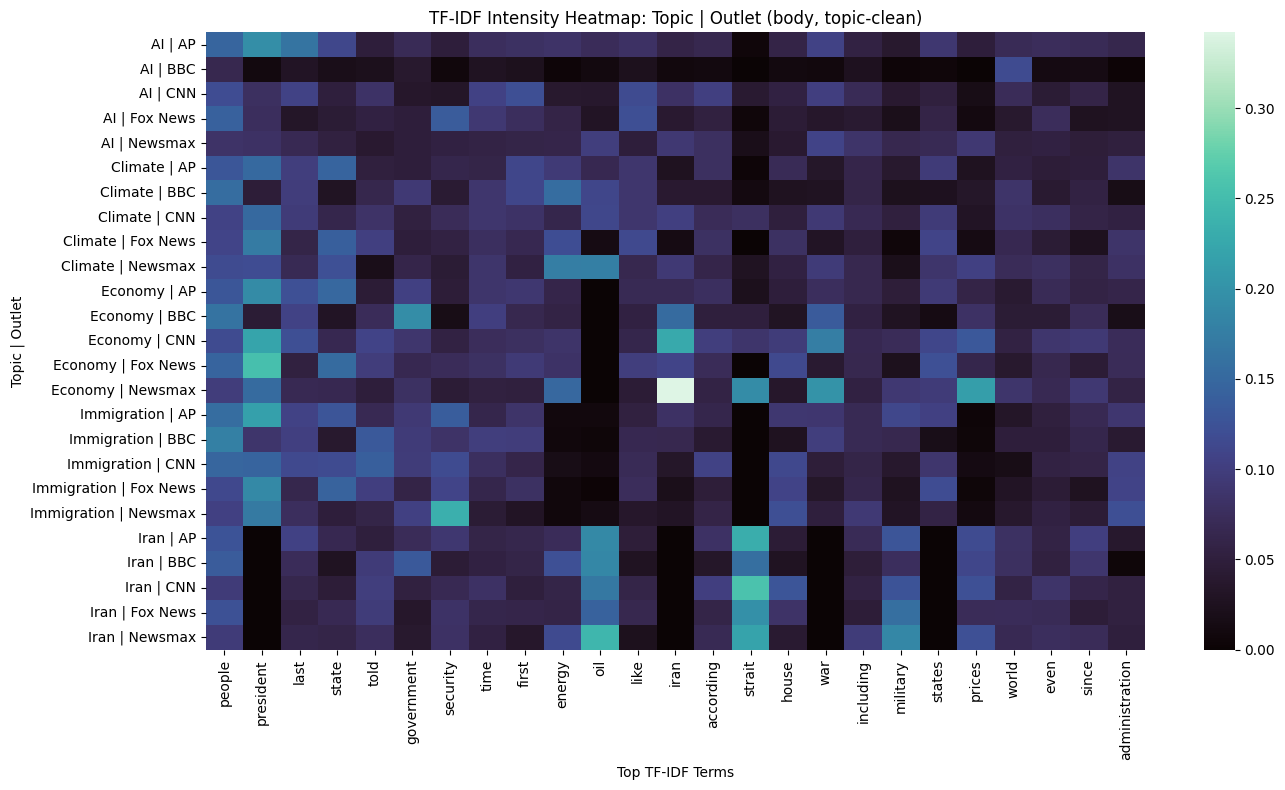

In [60]:
heat_df = df[['topic', 'outlet', 'article_text_topic_clean']].copy()
heat_df['topic_outlet'] = heat_df['topic'].astype(str) + ' | ' + heat_df['outlet'].astype(str)

grouped_docs = heat_df.groupby('topic_outlet', as_index=False)['article_text_topic_clean'].apply(
    lambda s: ' '.join(x for x in s.astype(str).tolist() if x)
)

vec_heat = TfidfVectorizer(min_df=1, use_idf=True)
X_heat   = vec_heat.fit_transform(grouped_docs['article_text_topic_clean'].tolist()).toarray()
mat_heat = pd.DataFrame(X_heat, index=grouped_docs['topic_outlet'].tolist(), columns=vec_heat.get_feature_names_out())

TOP_HEAT_TERMS = 25
top_cols       = mat_heat.sum(axis=0).sort_values(ascending=False).head(TOP_HEAT_TERMS).index.tolist()

plt.figure(figsize=(14, 8))
sns.heatmap(mat_heat[top_cols], cmap='mako')
plt.title('TF-IDF Intensity Heatmap: Topic | Outlet (body, topic-clean)')
plt.xlabel('Top TF-IDF Terms')
plt.ylabel('Topic | Outlet')
plt.tight_layout()
plt.show()


---
## Part 2: Per-Outlet Analysis Across All Topics

Aggregate all topics per outlet and compare sources on:
- Top terms by count and TF-IDF (body and headline)
- Average VADER sentiment
- Headline vs. body sentiment divergence

In [61]:
all_df = df.copy()
all_df['article_text']         = all_df['article_text'].astype(str).fillna('').str.strip()
all_df['headline_text']        = all_df['headline_text'].astype(str).fillna('').str.strip()
all_df['article_text_topic_clean']  = all_df.get('article_text_topic_clean',  pd.Series([''] * len(all_df), index=all_df.index)).astype(str).fillna('').str.strip()
all_df['headline_text_topic_clean'] = all_df.get('headline_text_topic_clean', pd.Series([''] * len(all_df), index=all_df.index)).astype(str).fillna('').str.strip()

all_df = all_df[
    (all_df['article_text_topic_clean'].str.len() > 0) |
    (all_df['headline_text_topic_clean'].str.len() > 0)
].copy()

outlet_docs_df = (
    all_df.groupby('outlet', as_index=False)
    .agg(
        all_events_article_text  = ('article_text_topic_clean',  lambda s: ' '.join(x for x in s if x)),
        all_events_headline_text = ('headline_text_topic_clean', lambda s: ' '.join(x for x in s if x)),
    )
)
outlet_docs_df['norm_article_text']  = outlet_docs_df['all_events_article_text']
outlet_docs_df['norm_headline_text'] = outlet_docs_df['all_events_headline_text']

outlet_docs_df[['outlet']].assign(
    article_token_count  = outlet_docs_df['norm_article_text'].str.split().str.len(),
    headline_token_count = outlet_docs_df['norm_headline_text'].str.split().str.len(),
)


,outlet,article_token_count,headline_token_count
0,AP,261035,4013
1,BBC,145632,2844
2,CNN,240438,3806
3,Fox News,179890,4092
4,Newsmax,136463,2759


#### Part 2A: Top Terms by Outlet (Count & TF-IDF)

In [62]:
outlet_names = outlet_docs_df['outlet'].tolist()

def print_top_terms(label, corpus_list):
    cv         = CountVectorizer(ngram_range=(1, 1), min_df=1)
    cv_matrix  = cv.fit_transform(corpus_list).toarray()
    cv_df      = pd.DataFrame(cv_matrix, index=outlet_names, columns=cv.get_feature_names_out())

    tfidf        = TfidfVectorizer(min_df=1, use_idf=True)
    tfidf_matrix = tfidf.fit_transform(corpus_list).toarray()
    tfidf_df     = pd.DataFrame(tfidf_matrix, index=outlet_names, columns=tfidf.get_feature_names_out())

    print(f'\n===== {label} =====')
    for out in outlet_names:
        print(f'Outlet: {out}')
        print('Top 10 terms by count:');   print(cv_df.loc[out].sort_values(ascending=False).head(10))
        print('\nTop 10 terms by TF-IDF:'); print(tfidf_df.loc[out].sort_values(ascending=False).head(10))
        print('\n' + '-'*60 + '\n')

print_top_terms('BODY TEXT (all events aggregated)',     outlet_docs_df['norm_article_text'].tolist())
print_top_terms('HEADLINE TEXT (all events aggregated)', outlet_docs_df['norm_headline_text'].tolist())



===== BODY TEXT (all events aggregated) =====
Outlet: AP
Top 10 terms by count:
people        978
state         857
president     849
last          835
first         621
security      557
government    542
according     527
military      525
trumps        521
Name: AP, dtype: int64

Top 10 terms by TF-IDF:
people        0.176583
state         0.154736
president     0.153291
last          0.150764
first         0.112125
trumps        0.111220
security      0.100569
government    0.097861
according     0.095153
military      0.094791
Name: AP, dtype: float64

------------------------------------------------------------

Outlet: BBC
Top 10 terms by count:
people        694
uk            672
government    539
last          410
world         375
time          374
told          373
first         358
home          329
energy        328
Name: BBC, dtype: int64

Top 10 terms by TF-IDF:
people        0.206949
uk            0.200389
government    0.160728
last          0.122261
world         0.1

#### Part 2B: Sentiment by Outlet (Body & Headline)

In [63]:
def score_text(series):
    return pd.DataFrame(series.apply(lambda x: sia.polarity_scores(x)).tolist())

sentiment_base = all_df[['outlet', 'article_text', 'headline_text']].copy()

body_scores = score_text(sentiment_base['article_text'])
body_scores.insert(0, 'outlet', sentiment_base['outlet'].values)
sentiment_by_outlet_body = (
    body_scores.groupby('outlet', as_index=False)[['compound', 'pos', 'neu', 'neg']]
    .mean().sort_values('compound', ascending=False)
)

headline_scores = score_text(sentiment_base['headline_text'])
headline_scores.insert(0, 'outlet', sentiment_base['outlet'].values)
sentiment_by_outlet_headline = (
    headline_scores.groupby('outlet', as_index=False)[['compound', 'pos', 'neu', 'neg']]
    .mean().sort_values('compound', ascending=False)
)

print('Body sentiment by outlet');    display(sentiment_by_outlet_body)
print('Headline sentiment by outlet'); display(sentiment_by_outlet_headline)


Body sentiment by outlet


,outlet,compound,pos,neu,neg
1,BBC,0.199613,0.089634,0.840751,0.069601
3,Fox News,0.025203,0.094240,0.814829,0.090910
0,AP,0.007177,0.087153,0.828771,0.084056
4,Newsmax,-0.046467,0.085766,0.823036,0.091193
2,CNN,-0.081273,0.083541,0.827085,0.089390


Headline sentiment by outlet


,outlet,compound,pos,neu,neg
1,BBC,-0.089114,0.081774,0.786389,0.131848
0,AP,-0.118301,0.074636,0.798384,0.126992
4,Newsmax,-0.123843,0.070728,0.784957,0.144328
2,CNN,-0.124049,0.056612,0.831497,0.111893
3,Fox News,-0.149138,0.086081,0.754067,0.159860


**Key findings:**
- *Body sentiment* is close to neutral overall. BBC is mildly positive (~+0.20); Fox/AP near neutral; Newsmax/CNN slightly negative.
- *Headline sentiment* is negative for all outlets. Most negative: Fox (−0.149) → CNN/Newsmax/AP; least negative: BBC (−0.089).
- Neutral dominates both layers (`neu` is high), so differences are mostly subtle tone shifts.
- Pattern: attention-grabbing/negative headline framing + comparatively neutral body framing across outlets.


### Charts 2–4: Sentiment Visuals (Part 2)

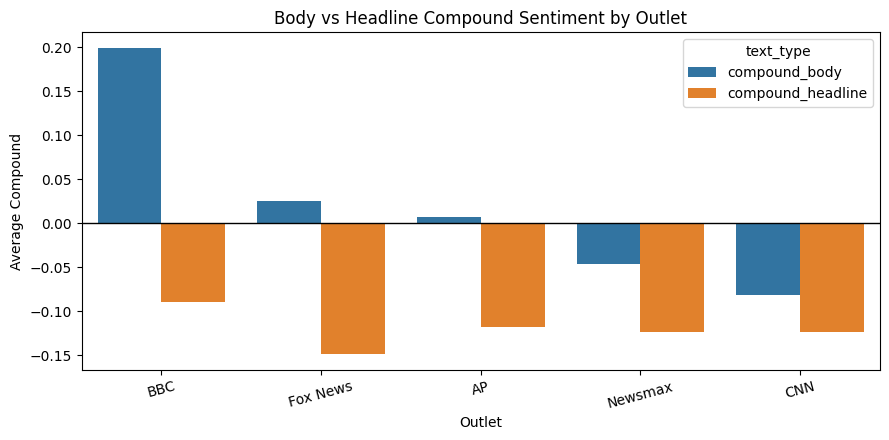

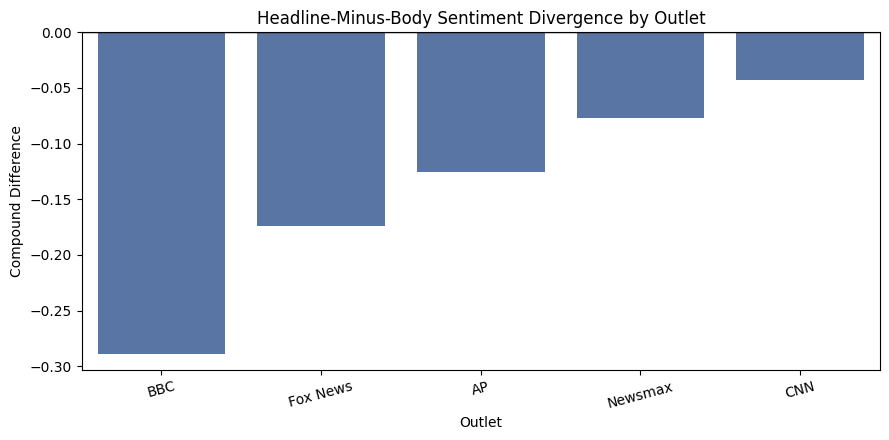

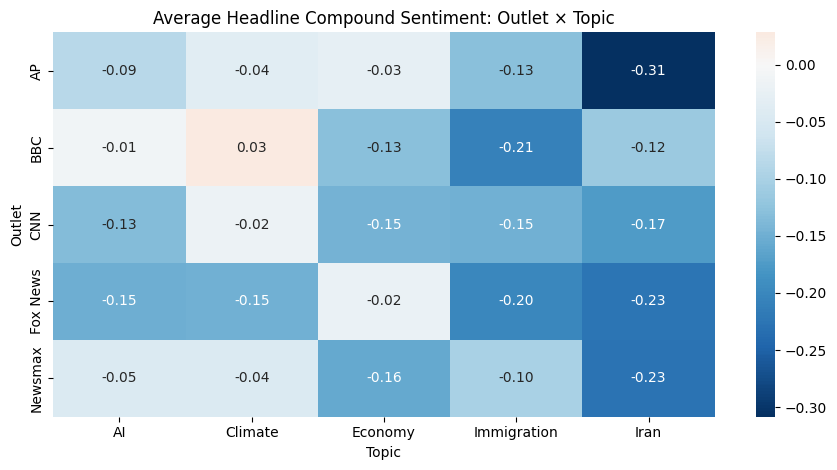

In [64]:
# Chart 2: Grouped bar — body vs headline compound sentiment
merged_sent = sentiment_by_outlet_body[['outlet', 'compound']].merge(
    sentiment_by_outlet_headline[['outlet', 'compound']], on='outlet', suffixes=('_body', '_headline')
)
long_sent = merged_sent.melt(
    id_vars='outlet', value_vars=['compound_body', 'compound_headline'],
    var_name='text_type', value_name='compound'
)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=long_sent, x='outlet', y='compound', hue='text_type')
plt.axhline(0, color='black', linewidth=1)
plt.title('Body vs Headline Compound Sentiment by Outlet')
plt.xlabel('Outlet'); plt.ylabel('Average Compound'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# Chart 3: Divergence bar — headline minus body
merged_sent['headline_minus_body'] = merged_sent['compound_headline'] - merged_sent['compound_body']

plt.figure(figsize=(9, 4.5))
sns.barplot(data=merged_sent.sort_values('headline_minus_body'), x='outlet', y='headline_minus_body', color='#4C72B0')
plt.axhline(0, color='black', linewidth=1)
plt.title('Headline-Minus-Body Sentiment Divergence by Outlet')
plt.xlabel('Outlet'); plt.ylabel('Compound Difference'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# Chart 4: Heatmap — outlet × topic average headline sentiment
temp = df[['outlet', 'topic', 'headline_text']].copy()
temp['headline_compound'] = temp['headline_text'].fillna('').apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)
heat = temp.groupby(['outlet', 'topic'])['headline_compound'].mean().unstack('topic')

plt.figure(figsize=(9, 4.8))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Average Headline Compound Sentiment: Outlet × Topic')
plt.xlabel('Topic'); plt.ylabel('Outlet')
plt.tight_layout(); plt.show()


### Part 2C: Headline vs. Body Divergence Deep-Dive

A focused divergence analysis: **divergence = headline_compound − body_compound**.  
Positive = headline is more negative than body (sensationalism).  
Negative = body is harsher than headline.


In [65]:
df2 = df.copy()
df2['outlet']   = df2['source_name'].astype(str)
df2['headline'] = df2['title_scraped'].astype(str).str.strip()
df2['body']     = df2['full_text'].astype(str).str.strip()
df2['topic']    = df2['topic'].astype(str).str.strip()
df2['date']     = pd.to_datetime(df2['publish_date'], errors='coerce')

df2 = df2[(df2['headline'].str.len() > 0) & (df2['body'].str.len() > 0)].copy()

df2['headline_compound'] = df2['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])
df2['body_compound']     = df2['body'].apply(lambda x: sia.polarity_scores(x)['compound'])
df2['divergence']        = df2['headline_compound'] - df2['body_compound']

print(f'Loaded {len(df2)} rows | Outlets: {sorted(df2["outlet"].unique())}')
df2[['outlet', 'topic', 'headline', 'headline_compound', 'body_compound', 'divergence']].head()


Loaded 2334 rows | Outlets: ['AP', 'BBC', 'CNN', 'Fox News', 'Newsmax']


,outlet,topic,headline,headline_compound,body_compound,divergence
0,AP,AI,Low-voltage utility elections face surge of attention as electricity bills rise,0.0000,0.9977,-0.9977
1,AP,AI,Wall Street's 2025 bonuses reached unprecedented levels in a rollicking year for markets,0.6124,0.9952,-0.3828
2,AP,AI,"Michigan license plate cameras face backlash: Big help, or Big Brother?",0.4019,0.9862,-0.5843
3,AP,AI,China's Alibaba targets $100B in AI and cloud revenue over 5 years,0.0000,0.9769,-0.9769
4,AP,AI,Nevada unveils new statewide data classification policy months after cyberattack,0.0000,0.9239,-0.9239


          mean_divergence     std    n
outlet                                
BBC               -0.2887  0.8030  429
Fox News          -0.1743  0.8616  479
AP                -0.1255  0.8314  484
Newsmax           -0.0774  0.8079  445
CNN               -0.0428  0.8274  497


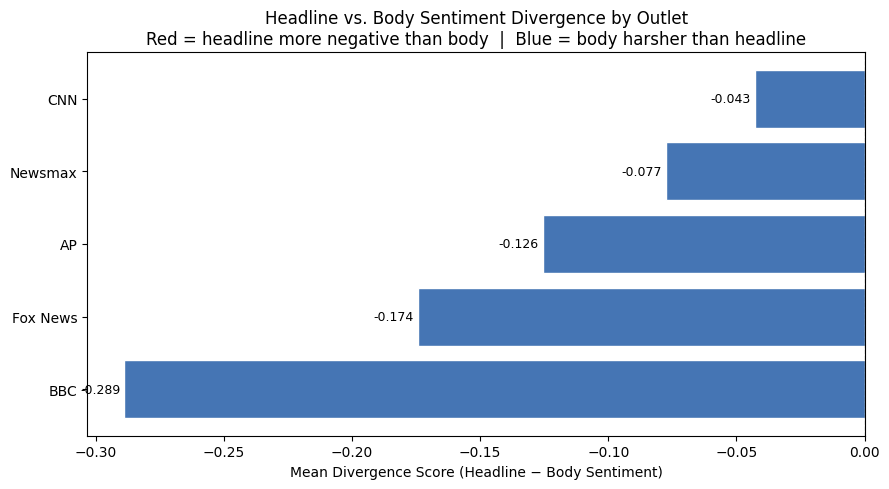

In [66]:
# Overall divergence by outlet
outlet_div = (
    df2.groupby('outlet')['divergence']
    .agg(mean_divergence='mean', std='std', n='count')
    .sort_values('mean_divergence').round(4)
)
print(outlet_div)

colors = ['#d73027' if v > 0 else '#4575b4' for v in outlet_div['mean_divergence']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(outlet_div.index, outlet_div['mean_divergence'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Divergence Score (Headline − Body Sentiment)')
ax.set_title('Headline vs. Body Sentiment Divergence by Outlet\n'
             'Red = headline more negative than body  |  Blue = body harsher than headline')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


topic        AI  Climate  Economy  Immigration   Iran
outlet                                               
AP       -0.523   -0.284   -0.202        0.142  0.185
BBC      -0.681   -0.617   -0.332        0.094  0.169
CNN      -0.301   -0.295   -0.038        0.139  0.277
Fox News -0.635   -0.421   -0.068        0.012  0.188
Newsmax  -0.487   -0.039    0.023       -0.060  0.197


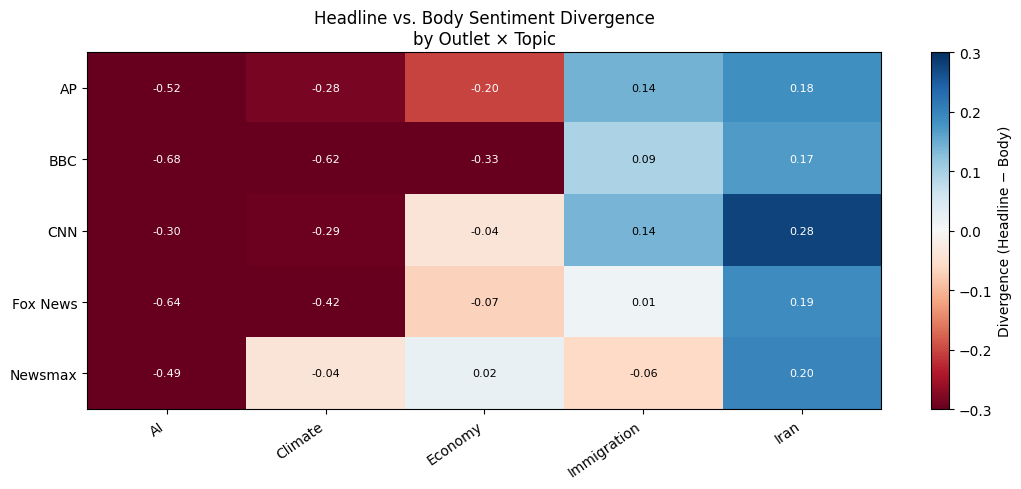

In [67]:
# Divergence heatmap — outlet × topic
pivot = (
    df2.groupby(['outlet', 'topic'])['divergence']
    .mean().unstack(fill_value=0).round(3)
)
print(pivot)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot.values, cmap='RdBu', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(pivot.values[i, j]) > 0.15 else 'black')
plt.colorbar(im, ax=ax, label='Divergence (Headline − Body)')
ax.set_title('Headline vs. Body Sentiment Divergence\nby Outlet × Topic')
plt.tight_layout(); plt.show()


In [68]:
# Top 3 most sensationalist headlines per outlet
print('── Top 3 Most Sensationalist Headlines per Outlet ──\n')
top_sensational = (
    df2.sort_values('divergence')
    .groupby('outlet').head(3)
    [['outlet', 'topic', 'headline', 'headline_compound', 'body_compound', 'divergence']]
)
for outlet, group in top_sensational.groupby('outlet'):
    print(f'  {outlet}')
    for _, row in group.iterrows():
        print(f'    [{row["topic"]}] {row["headline"][:90]}')
        print(f'    headline={row["headline_compound"]:.3f} | body={row["body_compound"]:.3f} | gap={row["divergence"]:.3f}\n')


── Top 3 Most Sensationalist Headlines per Outlet ──

  AP
    [Climate] Stop! Thief! Sharks Are Taking A Larger Bite Of Hawaii Fishermens Catch
    headline=-0.734 | body=0.987 | gap=-1.721

    [Iran] Analysis: Trump declares victory, no matter what, and the Iran war is the latest example
    headline=-0.718 | body=0.999 | gap=-1.717

    [Economy] Sean McDermott disparages call that led to Bills' loss and his firing
    headline=-0.743 | body=0.970 | gap=-1.713

  BBC
    [Climate] Labour and Plaid accuse each other of arrogance as election looms
    headline=-0.700 | body=0.993 | gap=-1.693

    [AI] Students worried about school cyber attack
    headline=-0.649 | body=0.942 | gap=-1.591

    [AI] How Hull helped families of Legacy funeral scandal recover
    headline=-0.660 | body=0.927 | gap=-1.587

  CNN
    [Iran] UK forced to halt Chagos Islands deal after Trump criticism | CNN
    headline=-0.710 | body=0.987 | gap=-1.696

    [AI] European leaders endure a new level of publi

C:\Users\woodj\AppData\Local\Temp\ipykernel_48672\1717490305.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=outlets, patch_artist=True, notch=False)


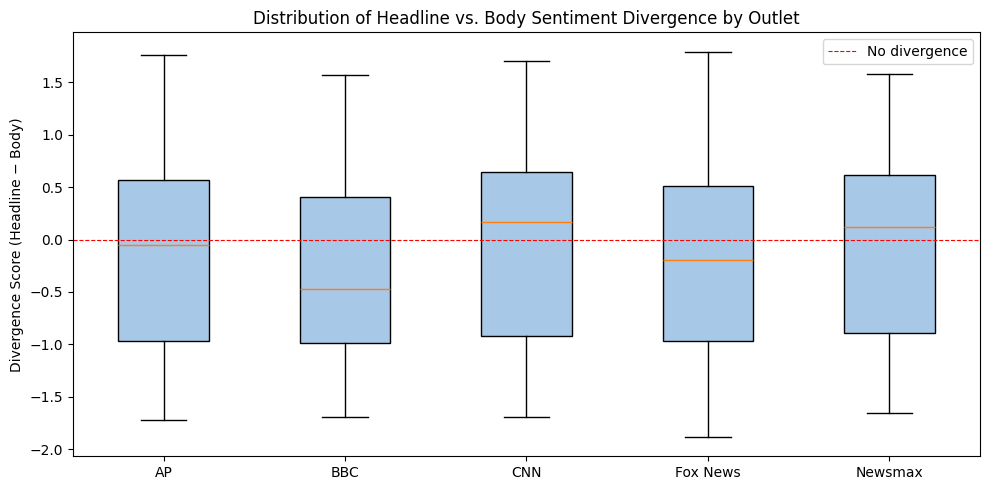

In [69]:
# Distribution of divergence scores per outlet (box plot)
outlets = sorted(df2['outlet'].unique())
data    = [df2[df2['outlet'] == o]['divergence'].dropna().values for o in outlets]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data, labels=outlets, patch_artist=True, notch=False)
for patch in bp['boxes']:
    patch.set_facecolor('#a8c8e8')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--', label='No divergence')
ax.set_ylabel('Divergence Score (Headline − Body)')
ax.set_title('Distribution of Headline vs. Body Sentiment Divergence by Outlet')
ax.legend(); plt.tight_layout(); plt.show()


---
## Part 3: Sub-Theme Extraction via Per-Topic NMF

Run Non-negative Matrix Factorization (NMF) **within each topic** to extract latent sub-themes and show how strongly each outlet emphasizes each sub-theme.

**Outputs per topic:**
- Top words per latent component (T1…T5)
- Outlet-topic proportions (normalized mean weights per outlet)

Runs separately on `article_text_topic_clean` (body) and `headline_text_topic_clean` (headline).


In [70]:
DEFAULT_N_COMPONENTS = 5
TOP_WORDS_PER_TOPIC  = 10

nmf_results = {}

def run_nmf_per_topic(df_in, text_col, n_components=DEFAULT_N_COMPONENTS, top_words=TOP_WORDS_PER_TOPIC):
    topics_local = sorted(df_in['topic'].dropna().unique())
    out = {}

    for topic_name in topics_local:
        part = df_in[df_in['topic'] == topic_name].copy()
        part = part[part[text_col].astype(str).str.strip().ne('')].copy()
        docs  = part[text_col].astype(str).tolist()
        n_docs = len(docs)

        if n_docs < 2:
            print(f"Skipping '{topic_name}' ({text_col}): not enough docs ({n_docs}).")
            continue

        vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)
        X = vectorizer.fit_transform(docs)

        if X.shape[1] < 2:
            print(f"Skipping '{topic_name}' ({text_col}): vocabulary too small ({X.shape[1]}).")
            continue

        k = min(n_components, X.shape[0] - 1, X.shape[1])
        if k < 2:
            print(f"Skipping '{topic_name}' ({text_col}): k would be < 2.")
            continue

        nmf_model = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=500)
        W = nmf_model.fit_transform(X)
        H = nmf_model.components_
        feature_names = vectorizer.get_feature_names_out()

        topic_words_df = pd.DataFrame([
            {'topic_component': f'T{i+1}',
             'top_words': ', '.join(feature_names[j] for j in H[i].argsort()[::-1][:top_words])}
            for i in range(len(H))
        ])

        doc_topic_df = pd.DataFrame(W, columns=[f'T{i+1}' for i in range(W.shape[1])])
        doc_topic_df.insert(0, 'outlet', part['outlet'].values)
        outlet_topic = doc_topic_df.groupby('outlet', as_index=False).mean()

        topic_cols = [c for c in outlet_topic.columns if c.startswith('T')]
        row_sums   = outlet_topic[topic_cols].sum(axis=1).replace(0, np.nan)
        outlet_topic[topic_cols] = outlet_topic[topic_cols].div(row_sums, axis=0).fillna(0)

        out[topic_name] = {
            'topic_words':            topic_words_df,
            'outlet_topic_proportions': outlet_topic,
            'n_docs':       n_docs,
            'n_components': k,
            'vocab_size':   X.shape[1],
        }

        print('\n' + '='*90)
        print(f'Topic: {topic_name} | Text: {text_col} | docs={n_docs} | k={k} | vocab={X.shape[1]}')
        print('='*90)
        print('Latent topics (top words):'); display(topic_words_df)
        print('Outlet-topic proportions:');  display(outlet_topic)

    return out

nmf_results['body']     = run_nmf_per_topic(df, 'article_text_topic_clean')
nmf_results['headline'] = run_nmf_per_topic(df, 'headline_text_topic_clean')



Topic: AI | Text: article_text_topic_clean | docs=458 | k=5 | vocab=20244
Latent topics (top words):


,topic_component,top_words
0,T1,"arts, sport, audio, culture, america, health culture, earth, travel, health, home"
1,T2,"data, people, like, information, security, free, power, use, google, state"
2,T3,"gout, touts chinas, mocks touts, chinese social, chinas rise, media mocks, alarming low, ocean sea, weir, bill weir"
3,T4,"oil, inflation, prices, fed, market, rate, war, iran, growth, economy"
4,T5,"anthropic, pentagon, claude, company, military, chain risk, amodei, supply chain, defense, chain"


Outlet-topic proportions:


,outlet,T1,T2,T3,T4,T5
0,AP,0.009252,0.405587,0.016877,0.435721,0.132563
1,BBC,0.842917,0.089609,0.007299,0.017680,0.042496
2,CNN,0.008017,0.246240,0.410554,0.207202,0.127987
3,Fox News,0.011374,0.676829,0.031449,0.139502,0.140846
4,Newsmax,0.008485,0.230902,0.013610,0.436913,0.310089



Topic: Climate | Text: article_text_topic_clean | docs=421 | k=5 | vocab=31485
Latent topics (top words):


...

,outlet,T1,T2,T3,T4,T5
0,AP,0.060473,0.391900,0.183549,0.220518,0.143559
1,BBC,0.043812,0.392055,0.117415,0.361561,0.085157
2,CNN,0.053549,0.365350,0.239693,0.194702,0.146706
3,Fox News,0.190444,0.287033,0.208871,0.185534,0.128118
4,Newsmax,0.364864,0.068685,0.115666,0.138349,0.312436



Topic: Iran | Text: headline_text_topic_clean | docs=459 | k=5 | vocab=683
Latent topics (top words):


,topic_component,top_words
0,T1,"hormuz, strait, strait hormuz, blockade, ships, trade, tehran, feel, deploys, near"
1,T2,"prices, oil, oil prices, lower, haiti, supplies, fall, decades, sharply, rise"
2,T3,"israel, lebanon, strikes, mass, israeli, expands, israel expands, talks, hezbollah, hold"
3,T4,"amid, middle, east, middle east, conflict, talks, energy, east conflict, military, global"
4,T5,"ceasefire, trumps, deal, democrats, analysis, gop, top, warns, ceasefire deal, plan"


Outlet-topic proportions:


,outlet,T1,T2,T3,T4,T5
0,AP,0.169253,0.170764,0.205953,0.227713,0.226316
1,BBC,0.143683,0.208592,0.249389,0.216885,0.181452
2,CNN,0.110043,0.144560,0.225235,0.142633,0.377530
3,Fox News,0.171549,0.026208,0.124569,0.272043,0.405631
4,Newsmax,0.086409,0.290768,0.186068,0.249167,0.187588


### Chart 5: NMF Outlet-Topic Proportions (Stacked Bar)

Change `SELECT_NMF_MODE` and `SELECT_NMF_TOPIC` to explore any topic/mode combination.

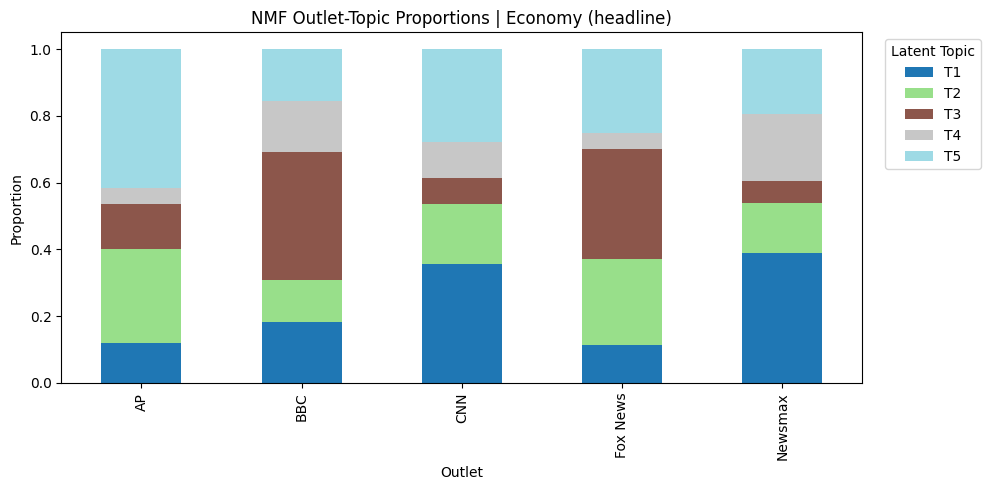

In [71]:
SELECT_NMF_MODE  = 'headline'  # 'body' or 'headline'
SELECT_NMF_TOPIC = 'Economy'   # any topic in nmf_results

blob = nmf_results.get(SELECT_NMF_MODE, {}).get(SELECT_NMF_TOPIC)
if not blob:
    print(f'No NMF results for mode={SELECT_NMF_MODE}, topic={SELECT_NMF_TOPIC}.')
else:
    mat   = blob['outlet_topic_proportions'].copy()
    tcols = [c for c in mat.columns if str(c).startswith('T')]
    mat   = mat.set_index('outlet')[tcols]

    ax = mat.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
    ax.set_title(f'NMF Outlet-Topic Proportions | {SELECT_NMF_TOPIC} ({SELECT_NMF_MODE})')
    ax.set_xlabel('Outlet'); ax.set_ylabel('Proportion')
    ax.legend(title='Latent Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(); plt.show()


### Body-Only NMF Interpretation (T1–T5 Across All Topics)

How to read it:
- `T1…T5` are latent sub-themes found by NMF.
- `top_words` defines each sub-theme's vocabulary.
- The `human_label` column (empty by default) can be filled in for reporting.


In [72]:
# Body-only NMF component map
rows = []
for main_topic, blob in nmf_results.get('body', {}).items():
    tw = blob['topic_words'].copy()
    tw['main_topic'] = main_topic
    rows.append(tw)

if rows:
    nmf_body_map = pd.concat(rows, ignore_index=True)[['main_topic', 'topic_component', 'top_words']]
    nmf_body_map = nmf_body_map.sort_values(['main_topic', 'topic_component']).reset_index(drop=True)
    nmf_body_map['human_label'] = ''  # fill manually for report-friendly labels
    display(nmf_body_map)
else:
    print('No body NMF results found. Run the NMF cell above first.')


,main_topic,topic_component,top_words,human_label
0,AI,T1,"arts, sport, audio, culture, america, health culture, earth, travel, health, home",
1,AI,T2,"data, people, like, information, security, free, power, use, google, state",
2,AI,T3,"gout, touts chinas, mocks touts, chinese social, chinas rise, media mocks, alarming low, ocean sea, weir, bill weir",
3,AI,T4,"oil, inflation, prices, fed, market, rate, war, iran, growth, economy",
4,AI,T5,"anthropic, pentagon, claude, company, military, chain risk, amodei, supply chain, defense, chain",
5,Climate,T1,"state, president, federal, democrats, house, newsom, funding, california, democratic, bill",
6,Climate,T2,"water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio",
7,Climate,T3,"epa, finding, endangerment, endangerment finding, zeldin, health, greenhouse, environmental, pollution, regulations",
8,Climate,T4,"energy, oil, gas, prices, iran, war, solar, wind, fuel, power",
9,Climate,T5,"greenland, denmark, arctic, nato, european, greenlands, minerals, trumps, danish, security",


In [73]:
# Custom human-readable labels for each body NMF component
custom_labels_by_topic = {
    'Economy': {
        'T1': 'Fiscal policy & social spending debate',
        'T2': 'Iran / Strait of Hormuz & oil supply risk',
        'T3': 'Monetary policy & inflation (Fed)',
        'T4': 'Epstein, house seats, congress, virginia',
        'T5': 'Latin America sanctions & tariffs',
    },
    'Immigration': {
        'T1': 'Federal enforcement & state pushback',
        'T2': 'Virginia, resigns congress, house seats',
        'T3': 'TSA / airport security & DHS funding',
        'T4': 'Channel, democrats, senate, funding',
        'T5': 'Videos, media mocks, addresses allegations',
    },
    'AI': {
        'T1': 'Lifestyle & culture verticals',
        'T2': 'Tech & digital products / data privacy',
        'T3': 'China rises',
        'T4': 'Macro economy & energy markets',
        'T5': 'Anthropic / AI defense & national security',
    },
    'Iran': {
        'T1': 'Iran–Israel conflict & nuclear talks',
        'T2': 'democratic, seats, speaks',
        'T3': 'media mocks, escapes north, daring escapes',
        'T4': 'Military & expert analysis (TV punditry)',
        'T5': 'Hormuz / oil supply disruption',
    },
    'Climate': {
        'T1': 'US politics & climate funding',
        'T2': 'Extreme weather & seasonal events',
        'T3': 'EPA regulation & endangerment finding',
        'T4': 'Energy mix & fossil fuel markets',
        'T5': 'Greenland / Arctic geopolitics',
    },
}


def plot_body_topic_chart_labeled(topic_name, labels_by_topic=None):
    """Plot stacked bar of NMF outlet-topic proportions for body text, with optional human labels."""
    blob = nmf_results.get('body', {}).get(topic_name)
    if not blob:
        print(f'No body NMF result found for topic: {topic_name}')
        return
    mat   = blob['outlet_topic_proportions'].copy()
    tcols = [c for c in mat.columns if str(c).startswith('T')]
    mat   = mat.set_index('outlet')[tcols]
    if labels_by_topic and topic_name in labels_by_topic:
        mat = mat.rename(columns=labels_by_topic[topic_name])
    ax = mat.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
    ax.set_title(f'NMF Outlet-Topic Proportions | {topic_name} (body)')
    ax.set_xlabel('Outlet'); ax.set_ylabel('Proportion')
    ax.legend(title='Latent Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(); plt.show()


#### Body NMF Charts — All Topics (Labeled)

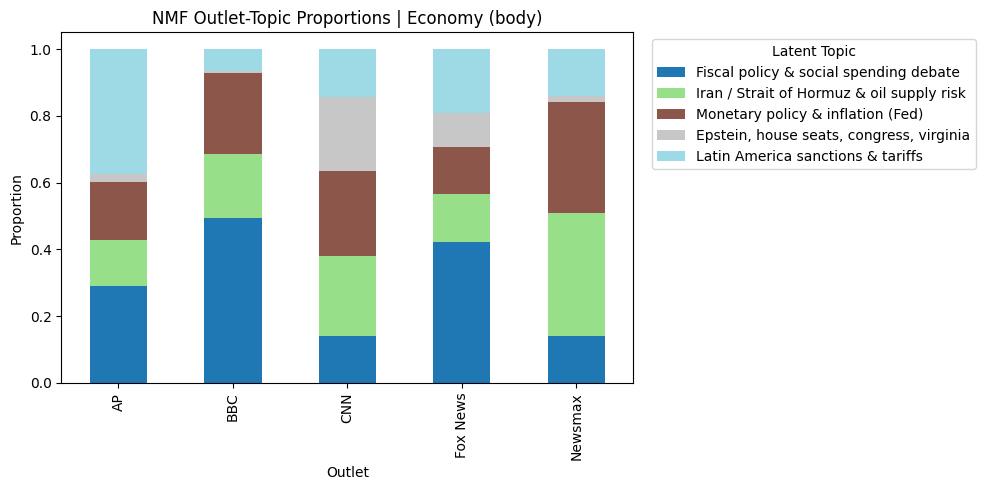

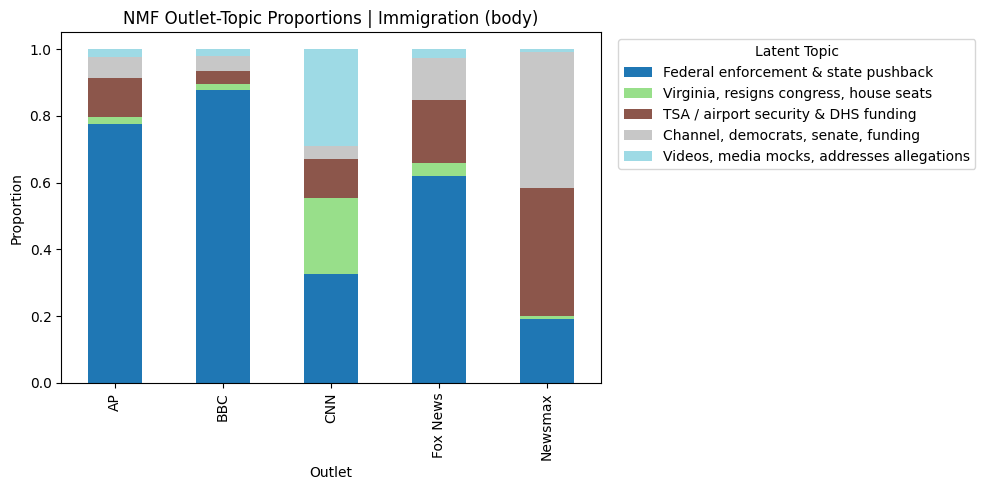

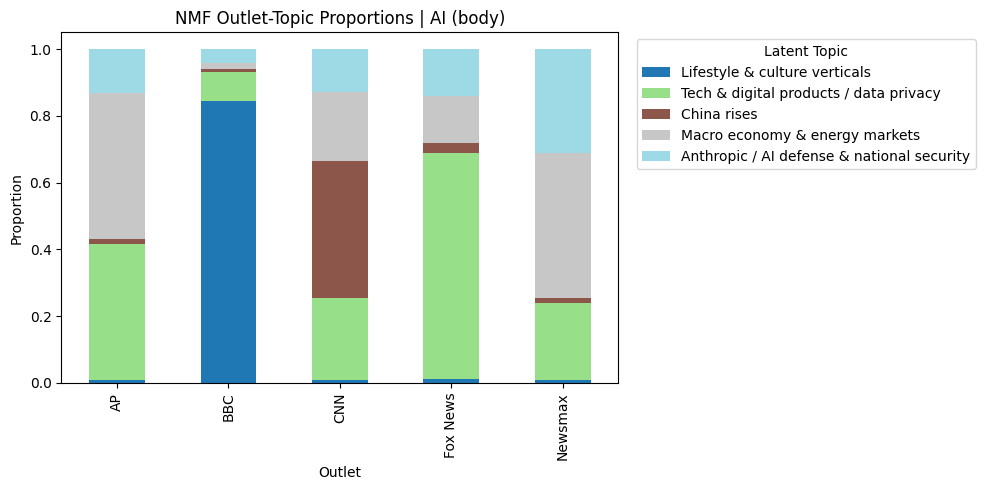

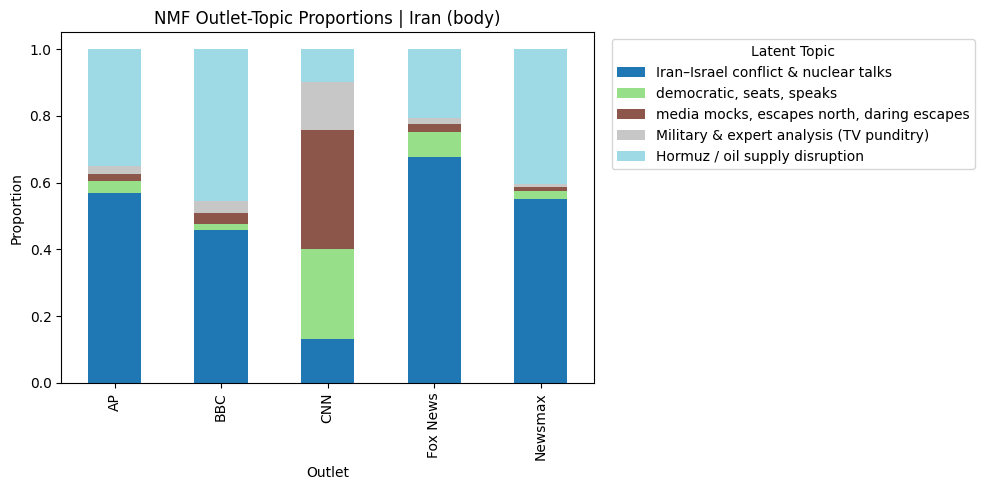

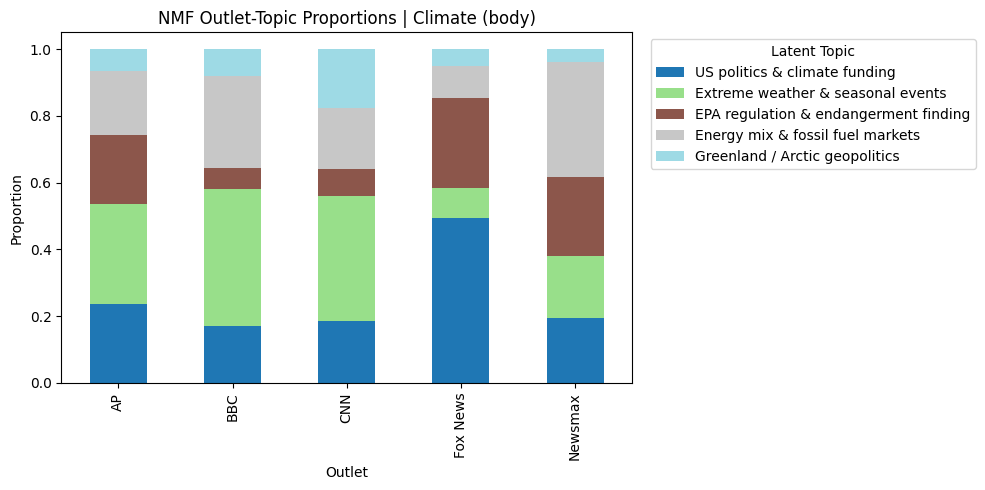

In [74]:
for t in ['Economy', 'Immigration', 'AI', 'Iran', 'Climate']:
    plot_body_topic_chart_labeled(t, custom_labels_by_topic)


In [75]:
# Body-only summary tables (full top words, copy-ready)
if 'body' not in nmf_results:
    print('No body NMF results found. Run the NMF cell above first.')
else:
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', 1000)

    component_rows = []
    dominant_rows  = []

    for t in sorted(nmf_results['body'].keys()):
        blob = nmf_results['body'][t]
        tw   = blob['topic_words'].copy()
        op   = blob['outlet_topic_proportions'].copy()

        tw['topic'] = t
        component_rows.append(tw[['topic', 'topic_component', 'top_words']])

        tcols    = [c for c in op.columns if str(c).startswith('T')]
        dominant = op.set_index('outlet')[tcols].idxmax(axis=1)
        words_lookup = dict(zip(tw['topic_component'], tw['top_words']))
        tmp = dominant.rename('dominant_component').to_frame().reset_index()
        tmp.insert(0, 'topic', t)
        tmp['dominant_top_words'] = tmp['dominant_component'].map(words_lookup)
        dominant_rows.append(tmp)

    body_component_table = pd.concat(component_rows, ignore_index=True)
    body_dominant_table  = pd.concat(dominant_rows,  ignore_index=True)
    body_component_wide  = (
        body_component_table
        .pivot(index='topic', columns='topic_component', values='top_words')
        .reset_index().sort_values('topic')
    )

    print('\n=== BODY NMF COMPONENTS (FULL TOP WORDS) ===')
    display(body_component_table.sort_values(['topic', 'topic_component']).reset_index(drop=True))

    print('\n=== BODY NMF DOMINANT COMPONENT BY OUTLET (WITH FULL TOP WORDS) ===')
    display(body_dominant_table.sort_values(['topic', 'outlet']).reset_index(drop=True))

    print('\n=== BODY NMF COMPONENTS (WIDE TABLE) ===')
    display(body_component_wide)

    body_component_table.to_excel('nmf_body_components_full.xlsx',     index=False)
    body_dominant_table.to_excel('nmf_body_dominant_by_outlet.xlsx',   index=False)
    body_component_wide.to_excel('nmf_body_components_wide.xlsx',      index=False)
    print('Saved: nmf_body_components_full.xlsx, nmf_body_dominant_by_outlet.xlsx, nmf_body_components_wide.xlsx')



=== BODY NMF COMPONENTS (FULL TOP WORDS) ===


,topic,topic_component,top_words
0,AI,T1,"arts, sport, audio, culture, america, health culture, earth, travel, health, home"
1,AI,T2,"data, people, like, information, security, free, power, use, google, state"
2,AI,T3,"gout, touts chinas, mocks touts, chinese social, chinas rise, media mocks, alarming low, ocean sea, weir, bill weir"
3,AI,T4,"oil, inflation, prices, fed, market, rate, war, iran, growth, economy"
4,AI,T5,"anthropic, pentagon, claude, company, military, chain risk, amodei, supply chain, defense, chain"
5,Climate,T1,"state, president, federal, democrats, house, newsom, funding, california, democratic, bill"
6,Climate,T2,"water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio"
7,Climate,T3,"epa, finding, endangerment, endangerment finding, zeldin, health, greenhouse, environmental, pollution, regulations"
8,Climate,T4,"energy, oil, gas, prices, iran, war, solar, wind, fuel, power"
9,Climate,T5,"greenland, denmark, arctic, nato, european, greenlands, minerals, trumps, danish, security"



=== BODY NMF DOMINANT COMPONENT BY OUTLET (WITH FULL TOP WORDS) ===


,topic,outlet,dominant_component,dominant_top_words
0,AI,AP,T4,"oil, inflation, prices, fed, market, rate, war, iran, growth, economy"
1,AI,BBC,T1,"arts, sport, audio, culture, america, health culture, earth, travel, health, home"
2,AI,CNN,T3,"gout, touts chinas, mocks touts, chinese social, chinas rise, media mocks, alarming low, ocean sea, weir, bill weir"
3,AI,Fox News,T2,"data, people, like, information, security, free, power, use, google, state"
4,AI,Newsmax,T4,"oil, inflation, prices, fed, market, rate, war, iran, growth, economy"
5,Climate,AP,T2,"water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio"
6,Climate,BBC,T2,"water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio"
7,Climate,CNN,T2,"water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio"
8,Climate,Fox News,T1,"state, president, federal, democrats, house, newsom, funding, california, democratic, bill"
9,Climate,Newsmax,T4,"energy, oil, gas, prices, iran, war, solar, wind, fuel, power"



=== BODY NMF COMPONENTS (WIDE TABLE) ===


topic_component,topic,T1,T2,T3,T4,T5
0,AI,"arts, sport, audio, culture, america, health culture, earth, travel, health, home","data, people, like, information, security, free, power, use, google, state","gout, touts chinas, mocks touts, chinese social, chinas rise, media mocks, alarming low, ocean sea, weir, bill weir","oil, inflation, prices, fed, market, rate, war, iran, growth, economy","anthropic, pentagon, claude, company, military, chain risk, amodei, supply chain, defense, chain"
1,Climate,"state, president, federal, democrats, house, newsom, funding, california, democratic, bill","water, snow, winter, weather, heat, temperatures, el, nio, cold, el nio","epa, finding, endangerment, endangerment finding, zeldin, health, greenhouse, environmental, pollution, regulations","energy, oil, gas, prices, iran, war, solar, wind, fuel, power","greenland, denmark, arctic, nato, european, greenlands, minerals, trumps, danish, security"
2,Economy,"tax, state, people, government, democrats, funding, care, republicans, school, budget","iran, iranian, strait, israel, war, irans, military, hormuz, strait hormuz, khamenei","prices, fed, rates, inflation, powell, energy, bank, price, rate, market","virginia, speaks, epstein, virginia voters, house, house seats, congress, map, resigns congress, redistricting","cuba, venezuela, cuban, maduro, president, island, china, venezuelas, tariffs, venezuelan"
3,Immigration,"state, minnesota, enforcement, people, law, court, agents, president, administration, officers","virginia, speaks, resigns congress, resigns, redistricting, dems, virginia voters, house seats, congress, map","tsa, airports, shutdown, airport, funding, security, dhs, officers, agents, democrats","channel, democrats, rob, cable, senate, funding, today, shows, find, meuser","videos, mocks touts, media mocks, mocks, chinese social, chinas rise, touts chinas, patel publicly, publicly addresses, addresses allegations"
4,Iran,"israel, lebanon, military, hezbollah, israeli, strait, irans, people, nuclear, talks","virginia, speaks, house, congress, virginia voters, house seats, map, voters, democratic, seats","gout, robot, chinas rise, chinese social, touts chinas, media mocks, mocks touts, escapes north, escapes, daring escapes","star, expert, warns, general, palestinian, military analyst, lebanese, amanpour, fmr, even worse","oil, prices, energy, strait, gas, fuel, global, hormuz, oil prices, strait hormuz"


Saved: nmf_body_components_full.xlsx, nmf_body_dominant_by_outlet.xlsx, nmf_body_components_wide.xlsx


---
## Part 4: Reporting TF-IDF Matrices + Excel Export

Build compact TF-IDF matrices (top terms only, topic-clean text) for reporting, then export all results to a timestamped Excel workbook.

**Matrices built:**
- Topic × outlet (body and headline)
- Outlet only across all topics (body and headline)


In [76]:
REPORT_TOP_TERMS = 40

def build_reporting_tfidf_matrix(df_in, text_col, label_col, top_terms=REPORT_TOP_TERMS):
    """Build a compact TF-IDF matrix grouped by label_col, keeping only the top global terms."""
    temp = df_in[[label_col, text_col]].copy()
    temp[text_col] = temp[text_col].astype(str).fillna('').str.strip()
    temp = temp[temp[text_col].str.len() > 0]

    grouped = temp.groupby(label_col, as_index=False)[text_col].apply(
        lambda s: ' '.join(x for x in s if x)
    )
    if grouped.empty:
        return pd.DataFrame()

    vec  = TfidfVectorizer(min_df=1, use_idf=True)
    X    = vec.fit_transform(grouped[text_col].tolist()).toarray()
    mat  = pd.DataFrame(X, index=grouped[label_col].tolist(), columns=vec.get_feature_names_out())
    top_cols = mat.sum(axis=0).sort_values(ascending=False).head(top_terms).index.tolist()
    return mat[top_cols].round(4)


df['topic_outlet'] = df['topic'].astype(str) + ' | ' + df['outlet'].astype(str)

report_topic_outlet_body     = build_reporting_tfidf_matrix(df, 'article_text_topic_clean',  'topic_outlet')
report_topic_outlet_headline = build_reporting_tfidf_matrix(df, 'headline_text_topic_clean', 'topic_outlet')
report_outlet_body           = build_reporting_tfidf_matrix(df, 'article_text_topic_clean',  'outlet')
report_outlet_headline       = build_reporting_tfidf_matrix(df, 'headline_text_topic_clean', 'outlet')

print('topic x outlet (body):',     report_topic_outlet_body.shape);     display(report_topic_outlet_body.head(10))
print('topic x outlet (headline):', report_topic_outlet_headline.shape); display(report_topic_outlet_headline.head(10))
print('outlet only (body):',        report_outlet_body.shape);           display(report_outlet_body)
print('outlet only (headline):',    report_outlet_headline.shape);       display(report_outlet_headline)


topic x outlet (body): (25, 40)


,people,president,last,state,told,government,security,time,first,energy,...,may,trumps,going,federal,make,hormuz,american,back,donald,public
AI | AP,0.1459,0.1946,0.1637,0.1111,0.0492,0.0704,0.0492,0.0755,0.0789,0.0831,...,0.0331,0.1163,0.0551,0.0782,0.0543,0.0056,0.0297,0.0602,0.0450,0.0501
AI | BBC,0.0643,0.0098,0.0304,0.0197,0.0214,0.0375,0.0071,0.0268,0.0232,0.0027,...,0.0125,0.0000,0.0080,0.0033,0.0259,0.0000,0.0018,0.0080,0.0045,0.0116
AI | CNN,0.1184,0.0785,0.1064,0.0497,0.0816,0.0358,0.0328,0.1054,0.1203,0.0378,...,0.0398,0.0362,0.0557,0.0821,0.0617,0.0366,0.0368,0.0537,0.0298,0.0537
AI | Fox News,0.1407,0.0756,0.0329,0.0434,0.0539,0.0483,0.1358,0.0910,0.0749,0.0581,...,0.0630,0.0153,0.0392,0.0501,0.0553,0.0046,0.0686,0.0378,0.0203,0.0399
AI | Newsmax,0.0831,0.0810,0.0679,0.0527,0.0398,0.0492,0.0539,0.0562,0.0597,0.0609,...,0.0843,0.0128,0.0445,0.0682,0.0316,0.0169,0.0386,0.0316,0.0316,0.0422
Climate | AP,0.1286,0.1500,0.0992,0.1446,0.0515,0.0493,0.0626,0.0598,0.1108,0.0936,...,0.0410,0.0888,0.0504,0.1331,0.0465,0.0029,0.0393,0.0432,0.0277,0.0621
Climate | BBC,0.1561,0.0463,0.0975,0.0284,0.0638,0.0931,0.0426,0.0869,0.1100,0.1552,...,0.0532,0.0000,0.0426,0.0269,0.0718,0.0082,0.0124,0.0568,0.0133,0.0266
Climate | CNN,0.1066,0.1503,0.0954,0.0619,0.0831,0.0530,0.0709,0.0876,0.0820,0.0625,...,0.0552,0.0684,0.0564,0.0393,0.0569,0.0608,0.0402,0.0530,0.0580,0.0324
Climate | Fox News,0.1090,0.1712,0.0590,0.1398,0.1026,0.0487,0.0552,0.0770,0.0667,0.1193,...,0.0295,0.0374,0.0423,0.1541,0.0462,0.0000,0.0731,0.0449,0.0423,0.0705
Climate | Newsmax,0.1168,0.1185,0.0689,0.1225,0.0191,0.0613,0.0440,0.0861,0.0536,0.1761,...,0.0823,0.0139,0.0230,0.0627,0.0364,0.0277,0.0766,0.0249,0.0402,0.0670


topic x outlet (headline): (25, 40)


,iran,war,dhs,oil,prices,energy,trumps,hormuz,israel,gop,...,china,conflict,minneapolis,tech,funding,shutdown,may,lebanon,bill,fed
AI | AP,0.0566,0.0766,0.0000,0.0693,0.0755,0.0153,0.0000,0.0000,0.0189,0.0000,...,0.0294,0.0000,0.0000,0.0809,0.0189,0.0228,0.0000,0.0,0.0000,0.0000
AI | BBC,0.0380,0.0411,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0723,0.0000,0.0000,0.0265,0.0,0.0253,0.0000
AI | CNN,0.1199,0.0811,0.0000,0.0367,0.0000,0.0162,0.0000,0.0219,0.0000,0.0000,...,0.0000,0.0000,0.0571,0.1428,0.0000,0.0000,0.0418,0.0,0.0200,0.0000
AI | Fox News,0.0680,0.0294,0.0000,0.0166,0.0181,0.0294,0.0363,0.0000,0.0000,0.0625,...,0.0283,0.0397,0.0000,0.1036,0.0000,0.0000,0.0000,0.0,0.0363,0.0000
AI | Newsmax,0.0722,0.0625,0.0000,0.1060,0.0578,0.0313,0.0000,0.0211,0.0000,0.0443,...,0.0601,0.0000,0.0000,0.1100,0.0000,0.0000,0.0201,0.0,0.0000,0.2347
Climate | AP,0.0256,0.0415,0.0000,0.0469,0.0000,0.0415,0.0171,0.0000,0.0000,0.0000,...,0.0266,0.0000,0.0000,0.0000,0.0171,0.0206,0.0000,0.0,0.0171,0.0000
Climate | BBC,0.0276,0.0000,0.0000,0.0507,0.0368,0.0448,0.0000,0.0000,0.0000,0.0000,...,0.0144,0.0000,0.0000,0.0000,0.0368,0.0000,0.0578,0.0,0.0368,0.0000
Climate | CNN,0.0259,0.0280,0.0440,0.0951,0.0000,0.0140,0.0518,0.0568,0.0173,0.0000,...,0.0674,0.0568,0.0000,0.0000,0.0346,0.0209,0.0723,0.0,0.0000,0.0263
Climate | Fox News,0.0143,0.0155,0.0486,0.0175,0.0000,0.0619,0.0572,0.0000,0.0000,0.0438,...,0.0298,0.0209,0.0000,0.0000,0.0191,0.0230,0.0000,0.0,0.0572,0.0000
Climate | Newsmax,0.0758,0.0547,0.0000,0.0619,0.0337,0.1094,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0337,0.0000,0.0000,0.0,0.0000,0.0000


outlet only (body): (5, 40)


,people,president,last,state,security,government,told,time,first,energy,...,strait,going,make,back,trumps,american,still,public,donald,added
AP,0.1766,0.1533,0.1508,0.1547,0.1006,0.0979,0.0682,0.0874,0.1121,0.0847,...,0.0562,0.0648,0.0603,0.0617,0.1112,0.0554,0.0655,0.0655,0.0551,0.0368
BBC,0.2069,0.0489,0.1223,0.0426,0.0564,0.1607,0.1112,0.1115,0.1068,0.0978,...,0.0388,0.0552,0.0793,0.0573,0.0000,0.0137,0.0567,0.0584,0.0256,0.0710
CNN,0.1544,0.1419,0.1333,0.0933,0.0939,0.0886,0.1350,0.1099,0.1011,0.0685,...,0.0810,0.0740,0.0640,0.0636,0.1128,0.0593,0.0650,0.0558,0.0775,0.0638
Fox News,0.1751,0.1499,0.0695,0.1416,0.1310,0.0700,0.1188,0.1035,0.1035,0.0851,...,0.0400,0.0721,0.0628,0.0711,0.0555,0.0921,0.0550,0.0625,0.0636,0.0729
Newsmax,0.1352,0.1255,0.0945,0.0894,0.1340,0.0954,0.0700,0.0763,0.0624,0.1315,...,0.1032,0.0524,0.0493,0.0524,0.0226,0.0781,0.0537,0.0524,0.0725,0.0477


outlet only (headline): (5, 40)


,iran,war,energy,dhs,oil,trumps,gop,prices,amid,first,...,shutdown,strikes,day,claims,council,plans,california,agents,may,america
AP,0.0873,0.1007,0.1007,0.0159,0.0873,0.0238,0.0000,0.0873,0.0403,0.0873,...,0.0238,0.0134,0.0635,0.0336,0.0000,0.0953,0.0635,0.0403,0.0134,0.0397
BBC,0.1247,0.0935,0.0702,0.0000,0.0624,0.0092,0.0000,0.0780,0.0468,0.0780,...,0.0000,0.0156,0.0276,0.0078,0.1963,0.0737,0.0000,0.0234,0.0312,0.0000
CNN,0.1886,0.1105,0.0325,0.0384,0.0780,0.2230,0.0366,0.0650,0.0715,0.0715,...,0.0461,0.0455,0.0923,0.0390,0.0000,0.0077,0.0308,0.0715,0.0585,0.0461
Fox News,0.0796,0.0306,0.0735,0.1376,0.0184,0.1231,0.2238,0.0061,0.0796,0.0674,...,0.0579,0.0551,0.0217,0.0857,0.0000,0.0000,0.0724,0.0429,0.0061,0.0434
Newsmax,0.3034,0.1669,0.1441,0.2153,0.1441,0.0000,0.1066,0.1214,0.0910,0.0228,...,0.0807,0.0759,0.0000,0.0379,0.0000,0.0179,0.0269,0.0152,0.0834,0.0628


In [77]:
# === Generate clean TF-IDF tables for reporting ===
TOP_N = 15  # terms to show per cell — tune up if you want longer lists


# --- Table 1: Aggregate TF-IDF by outlet — no global top-N filter ---

corpus_body  = outlet_docs_df['norm_article_text'].tolist()
corpus_head  = outlet_docs_df['norm_headline_text'].tolist()
outlet_names = outlet_docs_df['outlet'].tolist()

def per_outlet_top_terms(corpus_list, top_n=TOP_N):
    """Full per-outlet TF-IDF, top-N per outlet — no global filtering."""
    tfidf = TfidfVectorizer(min_df=1, use_idf=True)
    X     = tfidf.fit_transform(corpus_list).toarray()
    mat   = pd.DataFrame(X, index=outlet_names, columns=tfidf.get_feature_names_out())
    return mat.apply(
        lambda row: ', '.join(row.sort_values(ascending=False).head(top_n).index),
        axis=1,
    )

agg_table = pd.DataFrame({
    'outlet':              outlet_names,
    'top_body_terms':      per_outlet_top_terms(corpus_body, TOP_N).values,
    'top_headline_terms':  per_outlet_top_terms(corpus_head, TOP_N).values,
})

print('=== Table 1: Aggregate TF-IDF Signatures by Outlet ===')
display(agg_table)


# --- Table 2: Per-topic TF-IDF by outlet (one table per topic) ---

def trim_terms(s, n=TOP_N):
    return ', '.join(str(s).split(', ')[:n])

per_topic = topic_outlet_summary[['topic', 'outlet']].copy()
per_topic['top_body_terms']     = topic_outlet_summary['top_body_terms'].apply(trim_terms)
per_topic['top_headline_terms'] = topic_outlet_summary['top_headline_terms'].apply(trim_terms)

print('\n=== Table 2: TF-IDF Signatures by Outlet, Within Each Topic ===')
for topic in sorted(per_topic['topic'].unique()):
    sub = per_topic[per_topic['topic'] == topic].drop(columns='topic').reset_index(drop=True)
    print(f'\n--- {topic} ---')
    display(sub)


# --- Save both to Excel for review ---
with pd.ExcelWriter('tfidf_tables.xlsx', engine='openpyxl') as xls:
    agg_table.to_excel(xls,  sheet_name='Aggregate',     index=False)
    per_topic.to_excel(xls, sheet_name='By_Topic_Outlet', index=False)

print('\nSaved to tfidf_tables.xlsx')


=== Table 1: Aggregate TF-IDF Signatures by Outlet ===


,outlet,top_body_terms,top_headline_terms
0,AP,"people, state, president, last, first, trumps, security, government, according, military, since, many, israel, time, like","administration, energy, war, plans, world, big, say, iran, first, oil, prices, least, highlights, photos, top"
1,BBC,"people, uk, government, last, world, time, told, first, scotland, home, energy, since, wales, like, make","uk, council, england, iran, scottish, west, yorkshire, war, reform, south, six, ni, centre, headlines, prices"
2,CNN,"people, president, told, last, according, trumps, house, time, like, iran, first, war, security, state, even","trumps, iran, analysis, war, updates, reacts, day, say, even, oil, know, february, administration, democratic, change"
3,Fox News,"people, president, state, like, security, told, house, time, first, democrats, american, states, administration, data, energy","gop, dem, dhs, trumps, house, warns, liberal, republicans, claims, amid, iran, pushes, top, sen, calls"
4,Newsmax,"prices, iran, people, security, energy, president, military, war, including, strait, oil, administration, global, may, government","iran, dhs, war, energy, oil, fed, prices, tsa, gop, deal, funding, amid, mideast, stocks, may"



=== Table 2: TF-IDF Signatures by Outlet, Within Each Topic ===

--- AI ---


,outlet,top_body_terms,top_headline_terms
0,AP,"data, billion, people, last, company, oil, power, market, health, president, state, energy, growth, companies, war","deal, street, wall, big, world, plans, war, tech, use, google, stocks, amazon, billion, chatbot, oil"
1,BBC,"arts, audio, sport, america, culture, technology, earth, travel, health, home, ireland, australia, wales, africa, scotland","first, uk, hull, footage, media, social, explained, fan, help, shooting, west, centre, echo, shows, gets"
2,CNN,"gout, war, iran, ice, videos, company, people, world, social, reports, source, media, chinese, like, chinas","iran, mexico, crisis, public, make, war, tech, help, economy, chinas, warns, archives, shares, companies, minneapolis"
3,Fox News,"data, people, security, free, president, like, energy, american, iran, information, america, state, access, national, time","global, use, gets, iran, surge, google, president, tech, san, strikes, house, crisis, data, people, robots"
4,Newsmax,"anthropic, billion, company, inflation, pentagon, fed, oil, prices, technology, market, nvidia, rate, war, companies, amazon","fed, tech, anthropic, amazon, oil, fears, iran, openai, investment, china, meta, poll, nvidia, war, ceo"



--- Climate ---


...


--- Immigration ---


,outlet,top_body_terms,top_headline_terms
0,AP,"officers, court, people, agents, state, president, enforcement, minnesota, military, judge, law, administration, house, security, minneapolis","judge, agents, minneapolis, minnesota, deportation, military, border, republicans, man, court, officers, lead, house, crackdown, enforcement"
1,BBC,"people, police, uk, told, scotland, government, council, court, reform, war, president, security, last, agents, country","court, man, iran, crime, channel, arrested, uk, woman, council, backlash, denies, firm, russia, reform, agents"
2,CNN,"house, agents, minnesota, virginia, minneapolis, people, state, democrats, enforcement, told, videos, voters, democratic, senate, president","agents, senate, minnesota, death, democrats, trumps, administration, airport, white, texas, say, state, become, doj, shutdown"
3,Fox News,"agents, state, enforcement, law, president, illegal, dhs, senate, democrats, house, administration, people, states, minnesota, security","dhs, gop, minneapolis, dem, agents, senate, claims, illegal, power, congress, judge, shooting, suspect, minnesota, nyc"
4,Newsmax,"security, tsa, democrats, officers, funding, senate, dhs, enforcement, shutdown, channel, house, airports, president, administration, mullin","dhs, funding, tsa, shutdown, senate, democrats, dems, mullin, bill, protests, gop, officers, airports, may, high"



--- Iran ---


,outlet,top_body_terms,top_headline_terms
0,AP,"strait, oil, israel, prices, irans, lebanon, military, people, israeli, tuesday, hezbollah, talks, march, hormuz, last","ceasefire, prices, strait, hormuz, oil, talks, israel, lebanon, say, photos, world, energy, know, rate, threatens"
1,BBC,"israel, oil, lebanon, fuel, uk, ceasefire, strait, hezbollah, energy, prices, people, government, israeli, talks, minister","israel, talks, ceasefire, fuel, starmer, prices, oil, lebanon, energy, world, china, hormuz, shortages, uk, amid"
2,CNN,"virginia, house, strait, gout, oil, videos, military, prices, ceasefire, lebanon, speaks, chinese, people, source, congress","trumps, analysis, prices, israel, lebanon, gas, say, day, republicans, strikes, oil, election, military, school, hormuz"
3,Fox News,"strait, regime, hormuz, military, democrats, people, israel, irans, deal, conflict, nuclear, oil, republicans, house, attacks","trumps, hormuz, gop, strait, warns, calls, conflict, regime, amid, dhs, strikes, attack, inside, threat, attacks"
4,Newsmax,"oil, strait, military, israel, prices, energy, nuclear, hormuz, reported, tehran, conflict, wednesday, people, attacks, region","oil, prices, conflict, israel, strike, deal, talks, cut, energy, hormuz, mideast, ground, ukraine, strikes, russia"



Saved to tfidf_tables.xlsx


#### Data Balance Check — Articles by Topic and Outlet

C:\Users\woodj\AppData\Local\Temp\ipykernel_48672\4173928803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_counts,  x='topic',  y='n_articles', ax=axes[0], palette='Blues_d')
C:\Users\woodj\AppData\Local\Temp\ipykernel_48672\4173928803.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlet_counts, x='outlet', y='n_articles', ax=axes[1], palette='Greens_d')


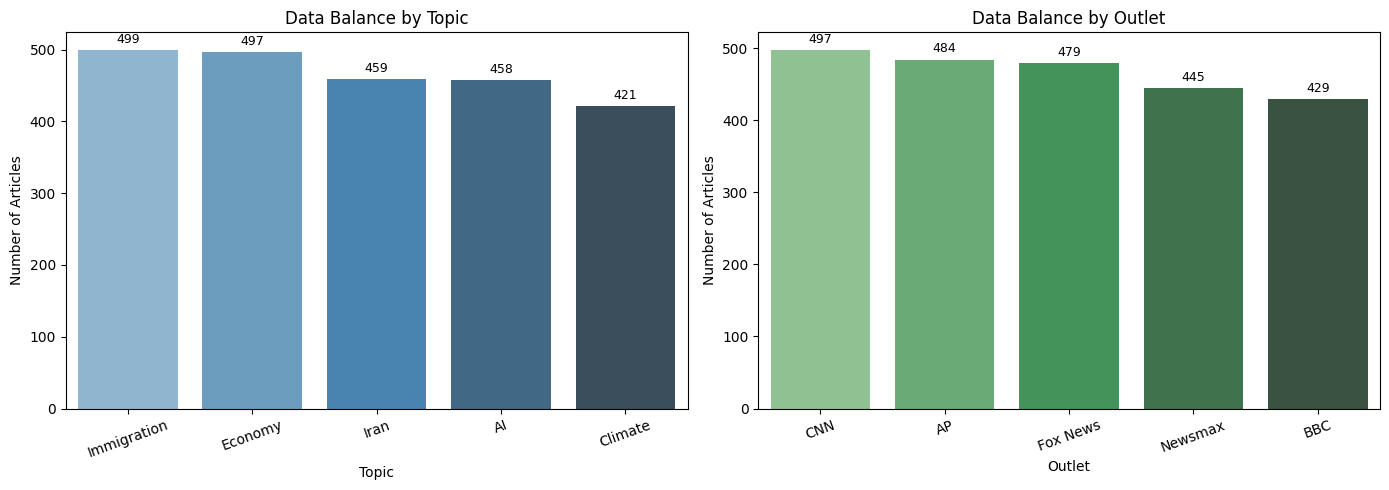

In [78]:
topic_counts  = df.groupby('topic').size().reset_index(name='n_articles').sort_values('n_articles', ascending=False)
outlet_counts = df.groupby('outlet').size().reset_index(name='n_articles').sort_values('n_articles', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=topic_counts,  x='topic',  y='n_articles', ax=axes[0], palette='Blues_d')
axes[0].set_title('Data Balance by Topic');  axes[0].set_xlabel('Topic');  axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=outlet_counts, x='outlet', y='n_articles', ax=axes[1], palette='Greens_d')
axes[1].set_title('Data Balance by Outlet'); axes[1].set_xlabel('Outlet'); axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=20)

for ax in axes:
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout(); plt.show()


#### Full Excel Export

In [79]:
out_path = f"nlp_results_full_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"

def safe_name(name):
    for c in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(c, ' ')
    return name[:31]

written = []

with pd.ExcelWriter(out_path, engine='openpyxl') as xls:
    if 'topic_outlet_summary' in globals():
        topic_outlet_summary.to_excel(xls, sheet_name='Part1_topic_outlet', index=False)
        written.append('Part1_topic_outlet')

    if 'sentiment_by_outlet_body' in globals():
        sentiment_by_outlet_body.to_excel(xls, sheet_name='Part2_sent_body', index=False)
        written.append('Part2_sent_body')

    if 'sentiment_by_outlet_headline' in globals():
        sentiment_by_outlet_headline.to_excel(xls, sheet_name='Part2_sent_head', index=False)
        written.append('Part2_sent_head')

    if 'nmf_results' in globals():
        for mode in ['body', 'headline']:
            if mode in nmf_results:
                for topic, blob in nmf_results[mode].items():
                    if isinstance(blob, dict):
                        tw = blob.get('topic_words')
                        op = blob.get('outlet_topic_proportions')
                        if isinstance(tw, pd.DataFrame):
                            s = safe_name(f'NMF_{mode}_{topic}_words')
                            tw.to_excel(xls, sheet_name=s, index=False); written.append(s)
                        if isinstance(op, pd.DataFrame):
                            s = safe_name(f'NMF_{mode}_{topic}_out')
                            op.to_excel(xls, sheet_name=s, index=False); written.append(s)

    for name, df_obj, sheet in [
        ('report_topic_outlet_body',     report_topic_outlet_body,     'P4_topic_outlet_body'),
        ('report_topic_outlet_headline', report_topic_outlet_headline, 'P4_topic_outlet_head'),
        ('report_outlet_body',           report_outlet_body,           'P4_outlet_body'),
        ('report_outlet_headline',       report_outlet_headline,       'P4_outlet_head'),
    ]:
        if name in globals():
            df_obj.to_excel(xls, sheet_name=sheet); written.append(sheet)

print('Wrote file:', out_path)
print('Sheets written:', written)


Wrote file: nlp_results_full_20260525_212758.xlsx
Sheets written: ['Part1_topic_outlet', 'Part2_sent_body', 'Part2_sent_head', 'NMF_body_AI_words', 'NMF_body_AI_out', 'NMF_body_Climate_words', 'NMF_body_Climate_out', 'NMF_body_Economy_words', 'NMF_body_Economy_out', 'NMF_body_Immigration_words', 'NMF_body_Immigration_out', 'NMF_body_Iran_words', 'NMF_body_Iran_out', 'NMF_headline_AI_words', 'NMF_headline_AI_out', 'NMF_headline_Climate_words', 'NMF_headline_Climate_out', 'NMF_headline_Economy_words', 'NMF_headline_Economy_out', 'NMF_headline_Immigration_words', 'NMF_headline_Immigration_out', 'NMF_headline_Iran_words', 'NMF_headline_Iran_out', 'P4_topic_outlet_body', 'P4_topic_outlet_head', 'P4_outlet_body', 'P4_outlet_head']


---
## Part 5: Moral Foundations Theory (MFT) Analysis

Score articles against five Moral Foundations Theory dictionaries and compare moral emphasis across outlets and topics.

| Dimension | Description |
|-----------|-------------|
| **Care** | Harm/care language |
| **Fairness** | Fairness/reciprocity/justice |
| **Ingroup** | Loyalty/patriotism/betrayal |
| **Order** | Authority/obedience/subversion |
| **Purity** | Sanctity/degradation/religion |


### MFT Dictionaries

In [80]:
dictionary_care = [
    'safe*', 'peace*', 'compassion*', 'empath*', 'sympath*', 'care*', 'caring', 'protect*',
    'shield', 'shelter', 'amity', 'benefit*', 'defen*', 'guard*', 'preserve', 'harm*', 'suffer*',
    'war', 'wars', 'warl*', 'warring', 'fight*', 'violen*', 'hurt*', 'kill', 'kills', 'killer*',
    'killed', 'killing', 'endanger*', 'cruel*', 'brutal*', 'abuse*', 'damag*', 'ruin*', 'ravage',
    'detriment*', 'crush*', 'attack*', 'annihilate*', 'destroy', 'stomp', 'abandon*', 'spurn',
    'impair', 'exploit', 'exploits', 'exploited', 'exploiting', 'wound*',
]

dictionary_fair = [
    'fair*', 'equal*', 'justice', 'justness', 'justifi*', 'reciproc*', 'impartial*', 'egalitar*',
    'rights', 'equity', 'evenness', 'equivalent', 'unbias*', 'tolerant', 'equable', 'balance*',
    'homologous', 'unprejudice*', 'reasonable', 'constant', 'honest*', 'unfair*', 'unequal*',
    'bias*', 'unjust*', 'injust*', 'bigot*', 'discriminat*', 'disproportion*', 'inequitable',
    'prejud*', 'dishonest', 'unscrupulous', 'dissociate', 'preference', 'favoritism', 'segregat*',
    'exclusion', 'exclud*',
]

dictionary_ingroup = [
    'together', 'nation*', 'homeland*', 'family', 'families', 'familial', 'group', 'loyal*',
    'patriot*', 'communal', 'commune*', 'communit*', 'communis*', 'comrad*', 'cadre', 'collectiv*',
    'joint', 'unison', 'unite*', 'fellow*', 'guild', 'solidarity', 'devot*', 'member', 'cliqu*',
    'cohort', 'ally', 'insider', 'foreign*', 'enem*', 'betray*', 'treason*', 'traitor*',
    'treacher*', 'disloyal*', 'individual*', 'apostasy', 'apostate', 'deserted', 'deserter*',
    'deserting', 'deceiv*', 'jilt*', 'imposter', 'miscreant', 'spy', 'sequester', 'renegade',
    'terroris*', 'immigra*', 'United States', 'America', 'American', 'Americans',
]

dictionary_order = [
    'obey*', 'obedien*', 'duty', 'law', 'lawful*', 'legal*', 'duti*', 'honor*', 'respect',
    'respectful*', 'respected', 'respects', 'order*', 'father*', 'mother', 'motherl*', 'mothering',
    'mothers', 'tradition*', 'hierarch*', 'authorit*', 'permit', 'permission', 'status*', 'rank*',
    'leader*', 'class', 'bourgeoisie', 'caste*', 'position', 'complian*', 'command', 'supremacy',
    'control', 'submi*', 'allegian*', 'serve', 'abide', 'defere*', 'defer', 'revere*', 'venerat*',
    'comply', 'defian*', 'rebel*', 'dissent*', 'subver*', 'disrespect*', 'disobe*', 'sediti*',
    'agitat*', 'insubordinat*', 'illegal*', 'lawless*', 'insurgent', 'mutinous', 'defy*',
    'dissident', 'unfaithful', 'alienate', 'defector', 'heretic*', 'nonconformist', 'oppose',
    'protest', 'refuse', 'denounce', 'remonstrate', 'riot*', 'obstruct', 'rule*', 'secur*',
]

dictionary_purity = [
    'piety', 'pious', 'purity', 'pure*', 'clean*', 'steril*', 'sacred*', 'chast*', 'holy',
    'holiness', 'saint*', 'wholesome*', 'celiba*', 'abstention', 'virgin', 'virgins', 'virginity',
    'virginal', 'austerity', 'integrity', 'modesty', 'abstinen*', 'abstemiousness', 'upright',
    'limpid', 'unadulterated', 'maiden', 'virtuous', 'refined', 'intemperate', 'decen*',
    'immaculate', 'innocent', 'pristine', 'humble', 'disgust*', 'deprav*', 'disease*', 'unclean*',
    'contagio*', 'indecen*', 'sin', 'sinful*', 'sinner*', 'sins', 'sinned', 'sinning', 'slut*',
    'whore', 'dirt*', 'impiety', 'impious', 'profan*', 'gross', 'repuls*', 'sick*', 'promiscu*',
    'lewd*', 'adulter*', 'debauche*', 'defile*', 'tramp', 'prostitut*', 'unchaste', 'wanton',
    'profligate', 'filth*', 'trashy', 'obscen*', 'lax', 'taint*', 'stain*', 'tarnish*', 'debase*',
    'desecrat*', 'wicked*', 'blemish', 'exploitat*', 'pervert', 'wretched*', 'Christ', 'god',
    'godly', 'Christian', 'bible', 'church', 'biblical', 'faith', 'sanct*',
]

DIMS   = ['care',   'fair',   'ingroup',            'order',           'purity']
LABELS = ['Caring & Protecting', 'Fairness & Equality', 'Loyalty & Patriotism', 'Order & Authority', 'Purity & Religiosity']
COLORS = ['#4472C4', '#7030A0', '#ED7D31', '#FFC000', '#FF0000']
DICTS  = [dictionary_care, dictionary_fair, dictionary_ingroup, dictionary_order, dictionary_purity]


### MFT Helper Functions

In [81]:
def normalize(text):
    """Lowercase, strip punctuation, return list of tokens."""
    return re.sub(r'[^a-z\s]', ' ', str(text).lower()).split()


def total_matches_per_doc(docs, dictionary):
    """
    Count MFT dictionary hits per document.
    Supports exact terms and prefix wildcards (e.g. 'care*').

    Parameters
    ----------
    docs       : list of lists of tokens (already tokenized)
    dictionary : iterable of terms; append '*' for prefix matching

    Returns
    -------
    list of int — total matches per document
    """
    dictionary  = set(dictionary)
    exact_terms = {t for t in dictionary if not t.endswith('*')}
    prefixes    = [t[:-1] for t in dictionary if t.endswith('*')]
    results = []
    for doc in docs:
        counts = Counter(doc)
        total  = sum(counts.get(t, 0) for t in exact_terms)
        total += sum(c for tok, c in counts.items() for p in prefixes if tok.startswith(p))
        results.append(total)
    return results


def bar_style(ax, title):
    """Apply shared clean style to grouped-bar axes."""
    ax.set_title(title, fontsize=14, fontweight='normal', pad=12)
    ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False)
    ax.set_ylabel('')
    legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
    ax.legend(
        handles=legend_patches, loc='upper center',
        bbox_to_anchor=(0.5, 1.15), ncol=5, frameon=False,
        fontsize=8.5, handlelength=0.9,
    )


### Part 5A: MFT Scores by Outlet

In [82]:
all_articles = (
    df.groupby('outlet', as_index=False)
    .agg(norm_article_text=('article_text', lambda s: ' '.join(x for x in s if x)))
)
all_articles['norm_article_text'] = all_articles['norm_article_text'].apply(normalize)


n = all_articles['norm_article_text'].apply(len)
for dim, dic in zip(DIMS, DICTS):
    all_articles[f'{dim}_matches'] = [
        m / l if l > 0 else 0
        for m, l in zip(total_matches_per_doc(all_articles['norm_article_text'], dic), n)
    ]

all_articles['moral_ratio'] = sum(all_articles[f'{d}_matches'] for d in DIMS)
all_articles[['outlet'] + [f'{d}_matches' for d in DIMS] + ['moral_ratio']].head()


,outlet,care_matches,fair_matches,ingroup_matches,order_matches,purity_matches,moral_ratio
0,AP,0.008887,0.001061,0.007400,0.007489,0.001102,0.025938
1,BBC,0.006965,0.001024,0.005258,0.005521,0.000715,0.019483
2,CNN,0.007918,0.001007,0.006277,0.006785,0.000996,0.022983
3,Fox News,0.008282,0.001407,0.007490,0.008510,0.000996,0.026685
4,Newsmax,0.009364,0.002569,0.007315,0.007832,0.000805,0.027886


### Part 5B: MFT Scores by Topic × Outlet

In [83]:
# Tokenize article_text_topic_clean for MFT scoring (consistent with outlet-level MFT)
df['article_tokens'] = df['article_text'].apply(normalize)
df['article_length'] = df['article_tokens'].apply(len)

for dim, dic in zip(DIMS, DICTS):
    df[f'{dim}_matches'] = total_matches_per_doc(df['article_tokens'], dic)

match_cols = [f'{d}_matches' for d in DIMS]
print(f"Scored {len(df):,} articles across {df['topic'].nunique()} topics and {df['source_name'].nunique()} outlets.")
df[['topic', 'source_name'] + match_cols + ['article_length']].head(3)


Scored 2,334 articles across 5 topics and 5 outlets.


,topic,source_name,care_matches,fair_matches,ingroup_matches,order_matches,purity_matches,article_length
0,AI,AP,1,0,5,6,3,1129
1,AI,AP,0,0,0,1,0,354
2,AI,AP,8,4,19,11,0,1450


In [84]:
topic_morals = (
    df[['topic', 'source_name'] + match_cols + ['article_length']]
    .groupby(['topic', 'source_name'], as_index=False).sum()
)

topic_morals['all_matches'] = topic_morals[match_cols].sum(axis=1)
for dim in DIMS:
    topic_morals[dim] = topic_morals[f'{dim}_matches'] / topic_morals['article_length']
topic_morals['all_values'] = topic_morals['all_matches'] / topic_morals['article_length']

topic_morals[['topic', 'source_name', 'care', 'fair', 'ingroup', 'order', 'purity', 'all_values']]


,topic,source_name,care,fair,ingroup,order,purity,all_values
0,AI,AP,0.006023,0.000926,0.005566,0.005899,0.001098,0.019512
1,AI,BBC,0.004950,0.000819,0.001912,0.002902,0.000580,0.011162
2,AI,CNN,0.006440,0.000800,0.003881,0.005408,0.000800,0.017328
3,AI,Fox News,0.007676,0.001387,0.005153,0.006623,0.000789,0.021628
4,AI,Newsmax,0.006122,0.002894,0.003839,0.006241,0.000571,0.019667
5,Climate,AP,0.006863,0.001114,0.006432,0.006880,0.001464,0.022754
6,Climate,BBC,0.005011,0.000744,0.004692,0.005463,0.000798,0.016709
7,Climate,CNN,0.006283,0.000902,0.005175,0.005666,0.001108,0.019133
8,Climate,Fox News,0.005868,0.002382,0.006897,0.007126,0.001600,0.023873
9,Climate,Newsmax,0.007706,0.001919,0.005882,0.007108,0.001290,0.023904


### Chart: MFT Heatmap — Moral Language Density by Topic × Outlet

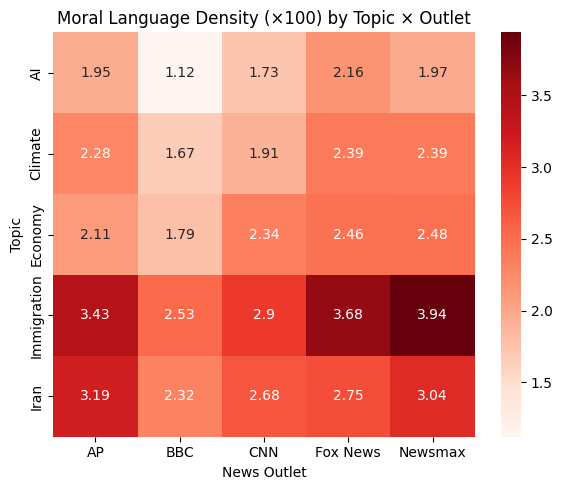

In [85]:
morality = topic_morals.pivot_table(
    index='topic', columns='source_name', values='all_values', aggfunc='sum'
)
morality = (morality * 100).round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(morality, cmap='Reds', annot=True, fmt='g')
plt.xlabel('News Outlet'); plt.ylabel('Topic')
plt.title('Moral Language Density (×100) by Topic × Outlet')
plt.tight_layout(); plt.show()


### Chart: MFT Grouped Bar — Values by Topic

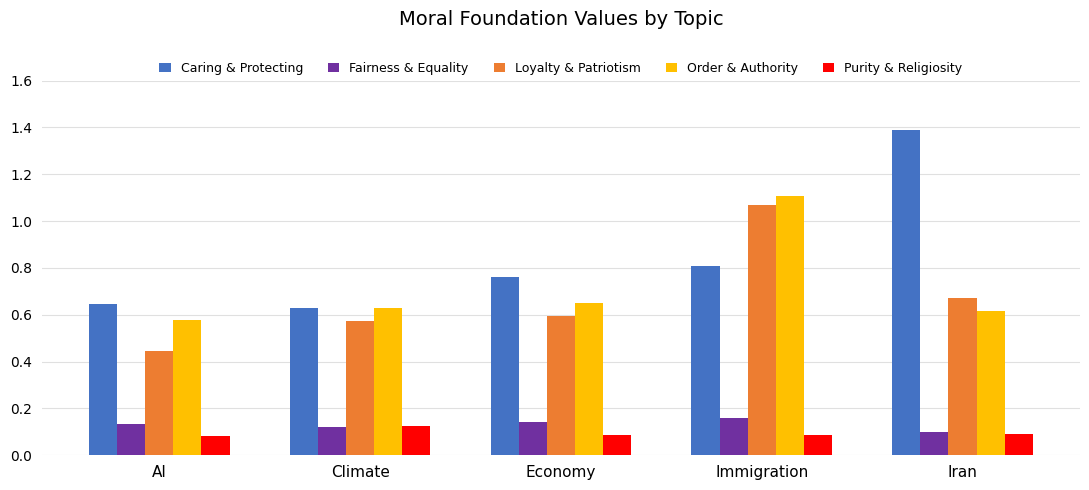

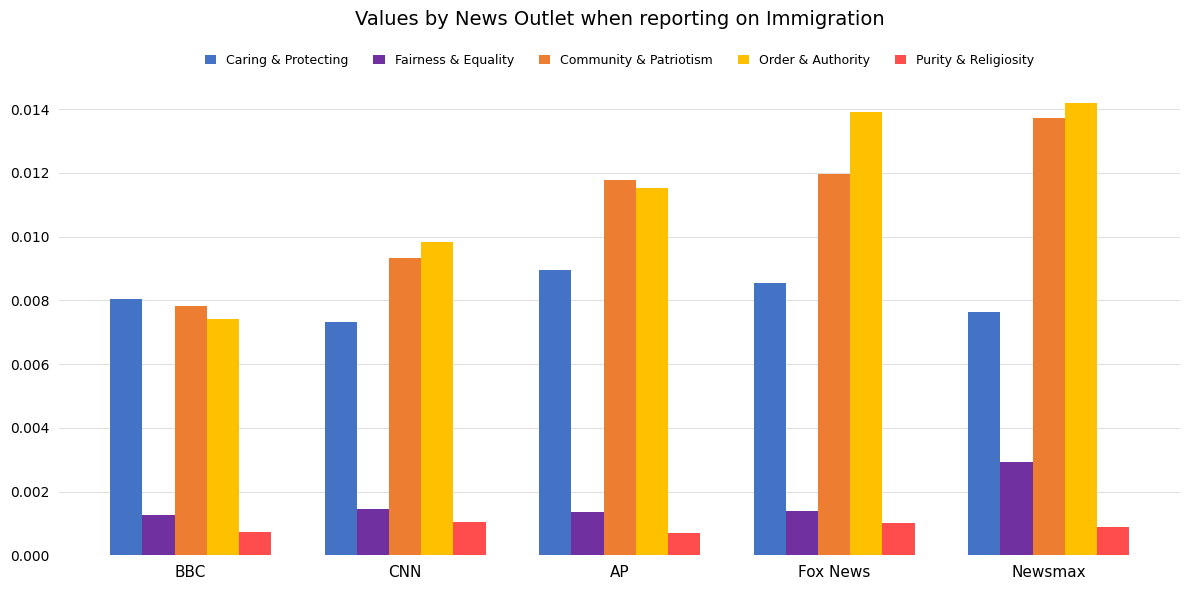

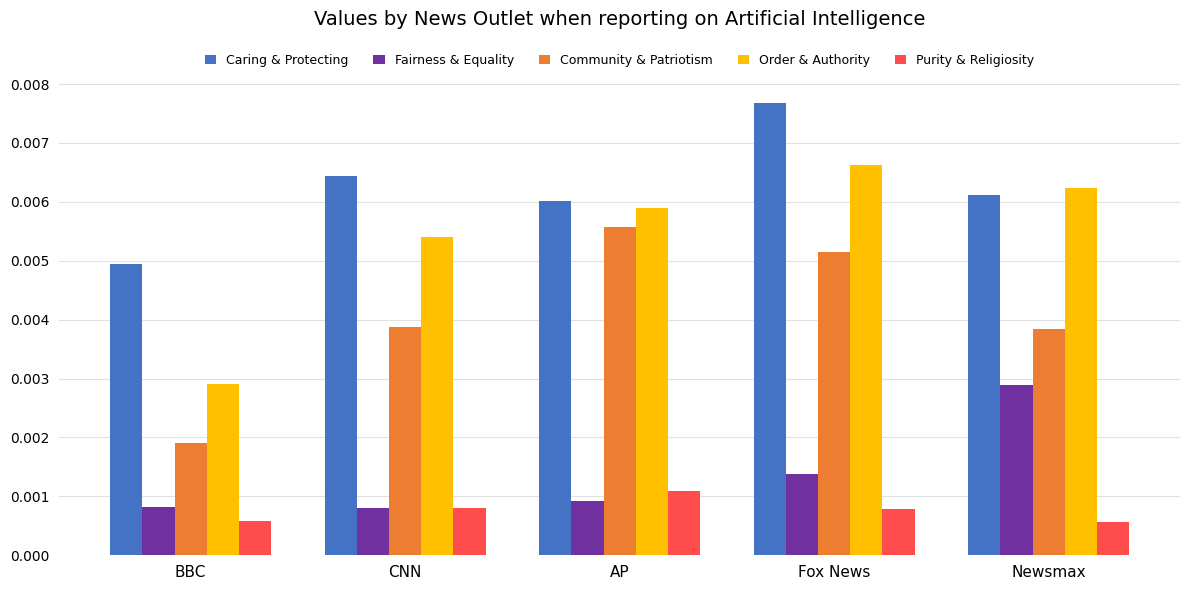

In [86]:

topic_df = (
    df[['topic', 'article_length'] + match_cols]
    .groupby('topic', as_index=False).sum()
)
for dim in DIMS:
    topic_df[dim] = (topic_df[f'{dim}_matches'] / topic_df['article_length']) * 100

topics_list = topic_df['topic'].tolist()
x           = np.arange(len(topics_list))
n_dims      = len(DIMS)
width       = 0.14
offsets     = np.linspace(-(n_dims - 1) / 2 * width, (n_dims - 1) / 2 * width, n_dims)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (dim, color, label) in enumerate(zip(DIMS, COLORS, LABELS)):
    ax.bar(x + offsets[i], topic_df[dim], width=width, color=color, label=label, zorder=3)

ax.set_title('Moral Foundation Values by Topic', fontsize=14, pad=40)
ax.set_xticks(x)
ax.set_xticklabels(topics_list, fontsize=11)
ax.set_ylim(0, 1.6)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.set_ylabel('')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    fontsize=9,
    handlelength=0.9,
)

plt.tight_layout()
plt.show()
# Pull Immigration data from the already-computed topic_morals dataframe
imm = topic_morals[topic_morals['topic'] == 'Immigration'].copy()
imm = imm.set_index('source_name')

dim_to_label = {
    'care':    'Caring & Protecting',
    'fair':    'Fairness & Equality',
    'ingroup': 'Community & Patriotism',
    'order':   'Order & Authority',
    'purity':  'Purity & Religiosity',
}

outlets = ['BBC', 'CNN', 'AP', 'Fox News', 'Newsmax']


data = {
    label: [imm.loc[o, dim] if o in imm.index else 0 for o in outlets]
    for dim, label in dim_to_label.items()
}

colors = {
    'Caring & Protecting':    '#4472C4',
    'Fairness & Equality':    '#7030A0',
    'Community & Patriotism': '#ED7D31',
    'Order & Authority':      '#FFC000',
    'Purity & Religiosity':   '#FF4C4C',
}

x       = np.arange(len(outlets))
n_dims  = len(data)
width   = 0.15
offsets = np.linspace(-(n_dims - 1) / 2 * width, (n_dims - 1) / 2 * width, n_dims)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (label, values) in enumerate(data.items()):
    ax.bar(x + offsets[i], values, width=width, color=colors[label], label=label, zorder=3)

ax.set_title('Values by News Outlet when reporting on Immigration', fontsize=14, pad=40)
ax.set_xticks(x)
ax.set_xticklabels(outlets, fontsize=11)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.set_ylabel('')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    fontsize=9,
    handlelength=0.9,
)

plt.tight_layout()
plt.show()


# Pull AI data from the already-computed topic_morals dataframe
imm = topic_morals[topic_morals['topic'] == 'AI'].copy()
imm = imm.set_index('source_name')

dim_to_label = {
    'care':    'Caring & Protecting',
    'fair':    'Fairness & Equality',
    'ingroup': 'Community & Patriotism',
    'order':   'Order & Authority',
    'purity':  'Purity & Religiosity',
}

outlets = ['BBC', 'CNN', 'AP', 'Fox News', 'Newsmax']


data = {
    label: [imm.loc[o, dim] if o in imm.index else 0 for o in outlets]
    for dim, label in dim_to_label.items()
}

colors = {
    'Caring & Protecting':    '#4472C4',
    'Fairness & Equality':    '#7030A0',
    'Community & Patriotism': '#ED7D31',
    'Order & Authority':      '#FFC000',
    'Purity & Religiosity':   '#FF4C4C',
}

x       = np.arange(len(outlets))
n_dims  = len(data)
width   = 0.15
offsets = np.linspace(-(n_dims - 1) / 2 * width, (n_dims - 1) / 2 * width, n_dims)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (label, values) in enumerate(data.items()):
    ax.bar(x + offsets[i], values, width=width, color=colors[label], label=label, zorder=3)

ax.set_title('Values by News Outlet when reporting on Artificial Intelligence', fontsize=14, pad=40)
ax.set_xticks(x)
ax.set_xticklabels(outlets, fontsize=11)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.set_ylabel('')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    fontsize=9,
    handlelength=0.9,
)

plt.tight_layout()
plt.show()

In [87]:
print(topic_morals[topic_morals['topic'] == 'Immigration']['source_name'].unique())


['AP' 'BBC' 'CNN' 'Fox News' 'Newsmax']


## Part 6: NRC Emotion Analysis

### Create Scores

In [88]:
from nrclex import NRCLex

EMOTIONS = ['anger', 'fear', 'disgust', 'sadness', 'joy', 'anticipation', 'surprise', 'trust']
OUTRAGE = ['anger', 'fear', 'disgust']

def nrc_density_scores(text):
    if not text or str(text).strip() == '':
        return {e: 0.0 for e in EMOTIONS}
    obj = NRCLex('x')
    obj.load_raw_text(str(text).lower())
    raw   = obj.raw_emotion_scores   # {emotion: raw count}
    total = len(obj.words) or 1      # total words in text (not just emotional ones)
    return {e: raw.get(e, 0) / total for e in EMOTIONS}

print("Scoring headlines (density)...")
headline_dens = df['headline_text'].apply(nrc_density_scores)
print("Scoring bodies (density, this takes a moment)...")
body_dens = df['article_text'].apply(nrc_density_scores)

for e in EMOTIONS:
    df[f'headline_{e}_dens'] = headline_dens.apply(lambda d: d[e])
    df[f'body_{e}_dens']     = body_dens.apply(lambda d: d[e])

df['headline_outrage_dens'] = df[[f'headline_{e}_dens' for e in OUTRAGE]].sum(axis=1)
df['body_outrage_dens']     = df[[f'body_{e}_dens'     for e in OUTRAGE]].sum(axis=1)
df['outrage_gap_dens']      = df['headline_outrage_dens'] - df['body_outrage_dens']

print("Done.")
df[['outlet', 'topic', 'headline_outrage_dens', 'body_outrage_dens', 'outrage_gap_dens']].head()

Scoring headlines (density)...
Scoring bodies (density, this takes a moment)...
Done.


,outlet,topic,headline_outrage_dens,body_outrage_dens,outrage_gap_dens
0,AP,AI,0.0,0.026930,-0.026930
1,AP,AI,0.0,0.026882,-0.026882
2,AP,AI,0.0,0.044828,-0.044828
3,AP,AI,0.0,0.022670,-0.022670
4,AP,AI,0.0,0.031955,-0.031955


### Density- fixed results

In [89]:
# Density-fixed NRC results: absolute scores and gaps by outlet and topic

headline_dens_cols = [f'headline_{e}_dens' for e in EMOTIONS]
body_dens_cols     = [f'body_{e}_dens'     for e in EMOTIONS]

headline_dens_by_outlet = df.groupby('outlet')[headline_dens_cols].mean().mul(100).round(2)
headline_dens_by_outlet.columns = EMOTIONS
body_dens_by_outlet = df.groupby('outlet')[body_dens_cols].mean().mul(100).round(2)
body_dens_by_outlet.columns = EMOTIONS

print("=== Headline Emotion Density by Outlet (per 100 words) ===")
display(headline_dens_by_outlet)
print("\n=== Body Emotion Density by Outlet (per 100 words) ===")
display(body_dens_by_outlet)

headline_dens_by_topic = df.groupby('topic')[headline_dens_cols].mean().mul(100).round(2)
headline_dens_by_topic.columns = EMOTIONS
body_dens_by_topic = df.groupby('topic')[body_dens_cols].mean().mul(100).round(2)
body_dens_by_topic.columns = EMOTIONS

print("\n=== Headline Emotion Density by Topic (per 100 words) ===")
display(headline_dens_by_topic)
print("\n=== Body Emotion Density by Topic (per 100 words) ===")
display(body_dens_by_topic)

print("\n=== Outrage Density Gap by Outlet (per 100 words) ===")
outlet_dens_gap = (
    df.groupby('outlet')[['headline_outrage_dens', 'body_outrage_dens', 'outrage_gap_dens']]
    .mean().mul(100).round(2).sort_values('outrage_gap_dens', ascending=False)
)
outlet_dens_gap.columns = ['headline_outrage', 'body_outrage', 'outrage_gap']
display(outlet_dens_gap)

=== Headline Emotion Density by Outlet (per 100 words) ===


,anger,fear,disgust,sadness,joy,anticipation,surprise,trust
outlet,,,,,,,,
AP,3.72,5.13,1.43,2.44,1.86,3.11,3.02,5.34
BBC,3.49,4.91,1.08,2.57,3.12,4.55,2.16,4.21
CNN,5.14,4.37,1.20,2.23,1.42,2.79,3.22,3.83
Fox News,5.06,6.48,1.77,3.32,2.27,3.77,3.65,5.75
Newsmax,4.41,5.90,1.15,2.57,2.00,3.97,3.60,4.90



=== Body Emotion Density by Outlet (per 100 words) ===


,anger,fear,disgust,sadness,joy,anticipation,surprise,trust
outlet,,,,,,,,
AP,2.08,3.11,0.82,1.65,1.53,2.69,1.36,4.70
BBC,1.88,3.25,0.64,1.83,2.26,3.65,1.44,4.03
CNN,2.25,3.05,0.92,1.59,1.45,2.60,1.83,4.21
Fox News,2.33,3.23,1.00,1.71,1.65,2.83,1.59,5.06
Newsmax,2.29,3.47,0.87,1.58,1.37,2.86,1.41,4.76



=== Headline Emotion Density by Topic (per 100 words) ===


,anger,fear,disgust,sadness,joy,anticipation,surprise,trust
topic,,,,,,,,
AI,3.23,4.23,1.10,2.28,2.06,3.53,2.38,4.50
Climate,3.39,5.11,1.68,2.32,2.27,3.68,3.16,4.54
Economy,4.39,4.91,1.53,2.81,2.57,4.33,3.19,5.13
Immigration,5.52,5.57,1.55,2.88,1.92,3.63,3.20,5.25
Iran,5.21,6.93,0.81,2.77,1.73,2.79,3.79,4.55



=== Body Emotion Density by Topic (per 100 words) ===


,anger,fear,disgust,sadness,joy,anticipation,surprise,trust
topic,,,,,,,,
AI,1.82,3.18,0.61,1.65,2.19,3.71,1.59,4.43
Climate,1.62,2.59,0.90,1.41,1.61,2.73,1.30,4.30
Economy,2.09,2.92,0.89,1.72,1.61,2.88,1.48,4.73
Immigration,2.71,3.51,1.12,1.91,1.49,2.67,1.57,4.84
Iran,2.52,3.82,0.73,1.60,1.32,2.56,1.71,4.43



=== Outrage Density Gap by Outlet (per 100 words) ===


,headline_outrage,body_outrage,outrage_gap
outlet,,,
Fox News,13.31,6.56,6.75
Newsmax,11.46,6.63,4.83
CNN,10.72,6.22,4.50
AP,10.28,6.01,4.27
BBC,9.48,5.77,3.71


### NRC Charts

In [90]:
import plotly.graph_objects as go

OUTLET_COLORS = {
    'AP':       '#636EFA',
    'BBC':      '#EF553B',
    'CNN':      '#00CC96',
    'Fox News': '#AB63FA',
    'Newsmax':  '#FFA15A',
}

outlets_sorted = sorted(df['outlet'].unique())
topics_list    = ['All'] + sorted(df['topic'].unique())
theta          = EMOTIONS + [EMOTIONS[0]]  # close the polygon
body_dens_cols = [f'body_{e}_dens' for e in EMOTIONS]

def body_dens_per_100(data):
    grp = data.groupby('outlet')[body_dens_cols].mean().mul(100)
    return {o: (grp.loc[o].tolist() if o in grp.index else [0.0]*len(EMOTIONS))
            for o in outlets_sorted}

topic_vals = {
    t: body_dens_per_100(df if t == 'All' else df[df['topic'] == t])
    for t in topics_list
}

fig = go.Figure()

for outlet in outlets_sorted:
    vals = topic_vals['All'][outlet]
    fig.add_trace(go.Scatterpolar(
        r     = vals + [vals[0]],
        theta = theta,
        name  = outlet,
        fill  = 'toself',
        fillcolor = OUTLET_COLORS[outlet],
        line  = dict(color=OUTLET_COLORS[outlet], width=2),
        opacity = 0.45,
    ))

buttons = []
for t in topics_list:
    r_list = []
    for outlet in outlets_sorted:
        vals = topic_vals[t][outlet]
        r_list.append(vals + [vals[0]])
    buttons.append(dict(
        label  = t,
        method = 'restyle',
        args   = [{'r': r_list}],
    ))

fig.update_layout(
    title = dict(text='Body Emotion Density by Outlet (per 100 words)', x=0.5),
    polar = dict(
        radialaxis = dict(visible=True, tickfont=dict(size=10)),
        angularaxis = dict(tickfont=dict(size=12)),
    ),
    updatemenus = [dict(
        type       = 'dropdown',
        direction  = 'down',
        x=0.01, y=1.18, xanchor='left',
        buttons    = buttons,
        showactive = True,
        bgcolor    = '#f0f0f0',
        font       = dict(size=12),
    )],
    annotations = [dict(
        text='Topic:', x=0.01, y=1.22, xref='paper', yref='paper',
        showarrow=False, font=dict(size=13),
    )],
    legend = dict(x=1.05, y=1.0),
    width=700, height=600,
)

fig.show()

In [91]:
import plotly.graph_objects as go

outlets_sorted = sorted(df['outlet'].unique())
topics_list    = ['All'] + sorted(df['topic'].unique())
theta          = EMOTIONS + [EMOTIONS[0]]
body_dens_cols = [f'body_{e}_dens' for e in EMOTIONS]

# Pre-compute all outlet × topic body densities (per 100 words)
all_vals = {}
for t in topics_list:
    tdf = df if t == 'All' else df[df['topic'] == t]
    grp = tdf.groupby('outlet')[body_dens_cols].mean().mul(100)
    for outlet in outlets_sorted:
        all_vals[(t, outlet)] = grp.loc[outlet].tolist() if outlet in grp.index else [0.0] * len(EMOTIONS)

max_val = max(max(v) for v in all_vals.values())
radial_cfg = dict(range=[0, 5.5], tickfont=dict(size=9))
angular_cfg = dict(tickfont=dict(size=12))

dropdown_style = dict(
    type='dropdown', direction='down',
    x=0.0, y=1.12, xanchor='left',
    showactive=True, bgcolor='#f0f0f0', font=dict(size=12),
)

# ── Chart 1: single radar, outlet dropdown (all topics combined) ──────────────
fig1 = go.Figure()
for o_idx, outlet in enumerate(outlets_sorted):
    vals = all_vals[('All', outlet)]
    fig1.add_trace(go.Scatterpolar(
        r         = vals + [vals[0]],
        theta     = theta,
        name      = outlet,
        fill      = 'toself',
        fillcolor = OUTLET_COLORS[outlet],
        line      = dict(color=OUTLET_COLORS[outlet], width=2.5),
        opacity   = 0.6,
        visible   = (o_idx == 0),
        showlegend= False,
    ))

outlet_buttons = []
for o_idx, outlet in enumerate(outlets_sorted):
    vis = [i == o_idx for i in range(len(outlets_sorted))]
    outlet_buttons.append(dict(label=outlet, method='update', args=[{'visible': vis}]))

fig1.update_layout(
    title       = dict(text='Body Emotion Density — All Topics (per 100 words)', x=0.5),
    polar       = dict(radialaxis=radial_cfg, angularaxis=angular_cfg),
    updatemenus = [{**dropdown_style, 'buttons': outlet_buttons}],
    annotations = [dict(text='Outlet:', x=-0.01, y=1.15, xref='paper', yref='paper',
                        showarrow=False, font=dict(size=13))],
    width=600, height=560,
)
fig1.show()

# ── Charts 2–6: one per outlet, topic dropdown ────────────────────────────────
for outlet in outlets_sorted:
    fig = go.Figure()
    for t_idx, t in enumerate(topics_list):
        vals = all_vals[(t, outlet)]
        fig.add_trace(go.Scatterpolar(
            r         = vals + [vals[0]],
            theta     = theta,
            name      = t,
            fill      = 'toself',
            fillcolor = OUTLET_COLORS[outlet],
            line      = dict(color=OUTLET_COLORS[outlet], width=2.5),
            opacity   = 0.6,
            visible   = (t_idx == 0),
            showlegend= False,
        ))

    topic_buttons = []
    for t_idx, t in enumerate(topics_list):
        vis = [i == t_idx for i in range(len(topics_list))]
        topic_buttons.append(dict(label=t, method='update', args=[{'visible': vis}]))

    fig.update_layout(
        title       = dict(text=f'{outlet} — Body Emotion Density (per 100 words)', x=0.5),
        polar       = dict(radialaxis=radial_cfg, angularaxis=angular_cfg),
        updatemenus = [{**dropdown_style, 'buttons': topic_buttons}],
        annotations = [dict(text='Topic:', x=-0.01, y=1.15, xref='paper', yref='paper',
                            showarrow=False, font=dict(size=13))],
        width=600, height=560,
    )
    fig.show()

## Part 7: NER Entity Recognition

### Setup

In [92]:
import spacy.cli
spacy.cli.download("en_core_web_sm")


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [93]:
import spacy
from collections import Counter

nlp = spacy.load('en_core_web_sm', disable=['tagger', 'parser', 'lemmatizer'])

ENTITY_TYPES = ['PERSON', 'ORG', 'GPE', 'NORP']

def extract_entities(texts, batch_size=64):
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        ents = [
            (ent.text.strip().title(), ent.label_)
            for ent in doc.ents
            if ent.label_ in ENTITY_TYPES and len(ent.text.strip()) > 1
        ]
        results.append(ents)
    return results

print("Running NER on article bodies (this takes a few minutes)...")
df['entities'] = extract_entities(df['article_text'].fillna('').tolist())
print(f"Done. Total articles: {len(df)}")
df[['outlet', 'topic', 'entities']].head(3)

Running NER on article bodies (this takes a few minutes)...
Done. Total articles: 2334


,outlet,topic,entities
0,AP,AI,"[(Ariz., GPE), (Ap, ORG), (Georgia, GPE), (New Jersey, GPE), (Virginia, GPE), (Arizona, GPE), (Alabama, GPE), (Turning Point Action, ORG), (Donald Trump, PERSON), (Phoenix, GPE), (Salt River Project, ORG), (Georgia, GPE), (Dave Pomerantz, PERSON), (The Energy And Policy Institute, ORG), (Arizona, GPE), (Salt River Project, ORG), (Phoenix, GPE), (Turning Point Action, ORG), (The Jane Fonda Climate Pac, ORG), (Jimmy Lindblom, PERSON), (Arizonans, NORP), (Arizona, GPE), (Arizonans, NORP), (Salt River Projects, ORG), (Randy Miller, PERSON), (Tempe, GPE), (Laura Kajfez, PERSON), (Tempe, GPE), (Srp, ORG), (Alabama, GPE), (Republican, NORP), (Alabama, GPE), (The Alabama Public Service Commission, ORG), (Alabama, GPE), (The U.S. Energy Information Administration, ORG), (Georgia, GPE), (Democrats, NORP), (U.S., GPE), (Doug Jones, PERSON), (Democratic, NORP), (Alabama, GPE), (Republicans, NORP), (Psc, ORG), (Georgia, GPE), (Psc, ORG), (Jones, PERSON), (Kay Ivey, PERSON), (Republican, NORP), (The Alabama Legislature Passed Hb475, ORG), (Alabama, GPE), (The Public Service Commission, ORG), (Ivey, ORG), (House, ORG), (Nathaniel Ledbetter, PERSON), (Senate, ORG), (Pro Tem, PERSON), (Garlan Gudger, PERSON), (Republican, NORP), (Democratic, NORP), (Democrats, NORP), (Georgias, PERSON), (Gop, ORG), (Alabama, GPE), (Georgia, GPE), (Alabama, GPE), (Tabitha Isner, PERSON), (The Alabama Democratic Party, ORG), (Levy, PERSON), (Harrisburg, GPE), (Pa., GPE), (Chandler, PERSON), (Montgomery, GPE), (Ala., GPE)]"
1,AP,AI,"[(New York, GPE), (Thomas Dinapolis, PERSON), (New York City, GPE), (Dinapoli, ORG), (Democrat, NORP), (Dinapoli, ORG), (Donald Trumps, PERSON), (Chris Connors, PERSON), (Johnson Associates, ORG), (Connors, ORG), (New York Citys, ORG), (Dinapoli, ORG)]"
2,AP,AI,"[(Michigan, GPE), (Michigan, GPE), (Flock Safety Of Atlanta, ORG), (Trump, ORG), (Media, ORG), (Immigration And Customs Enforcement, ORG), (Linda Berker, PERSON), (The Lapeer County Commission, ORG), (Bay City, GPE), (Flock, PERSON), (Detroit, GPE), (Todd Bettison, PERSON), (Waterford Township Police, ORG), (Scott Underwood, PERSON), (Flock, PERSON), (Kerry Mccormack, PERSON), (Flock, ORG), (Cleveland City Council, ORG), (Lapeer County, GPE), (Social Security, ORG), (Mccormack, ORG), (Flock, PERSON), (Mccormack, ORG), (Us, GPE), (Border Patrol, PERSON), (Michigan, GPE), (Associated Press, ORG), (Gabrielle Dresner, PERSON), (Aclu, ORG), (Michigan, GPE), (Dresner, PERSON), (Waterford Township, GPE), (Flock Os-Plus, ORG), (Cruiser Dashcams, ORG), (The Waterford School District, ORG), (Dennis Emmi, PERSON), (Axon, PERSON), (Emmi, PERSON), (Bridge Michigan, PERSON), (Flock, PERSON), (Sarah Hamid, PERSON), (The Electronic Frontier Foundation, ORG), (Hamid, PERSON), (An Electronic Frontier Foundation, ORG), (The Grand Rapids Police Department, ORG), (The Michigan Advance, ORG), (Flock, ORG), (Lapeer County, GPE), (Scott Mckenna, PERSON), (Scott Mcmahan, PERSON), (The National Conference Of State Legislatures, ORG), (Michigan, GPE), (Hamid, PERSON), (The Electronic Frontier Foundation, ORG), (Hamid, PERSON), (Bridge Michigan, PERSON), (The Associated Press, ORG)]"


### Normalization + Build df

In [94]:
# Normalize entity variants and remove artifacts before building ent_df

ENTITY_NORMALIZE = {
    # Person variants
    'trump':            'Donald Trump',
    'trumps':           'Donald Trump',
    'donald trump':     'Donald Trump',
    'donald trumps':    'Donald Trump',
    'biden':            'Joe Biden',
    'joe biden':        'Joe Biden',
    'rubio':            'Marco Rubio',
    'marco rubio':      'Marco Rubio',
    'keir':             'Keir Starmer',
    'keir starmer':     'Keir Starmer',
    'powell':           'Jerome Powell',
    'jerome powell':    'Jerome Powell',
    'netanyahu':        'Netanyahu',
    # GPE variants
    'u.s.':                  'United States',
    'us':                    'United States',
    'the united states':     'United States',
    'united states':         'United States',
    'america':               'United States',
    # ORG variants
    'the white house':       'White House',
    'fox news digital':      'Fox News',
    'u.n.':                  'UN',
    'the u.n.':              'UN',
    'united nations':        'UN',
    'the department of homeland security': 'DHS',
    # NORP possessives
    'irans':                 'Iranian',
    'israels':               'Israeli',
}

ENTITY_BLOCKLIST = {
    # Outlet self-references
    'ap', 'bbc', 'cnn', 'fox', 'fox news', 'newsmax', 'reuters',
    'associated press', 'the associated press', 'thomson/reuters',
    # BBC navigation/scraping artifacts
    'watch live', 'bbc maestro', 'video live documentaries',
    'video live documentaries home news us & canada',
    'video watch documentaries', 'india australia', 'the mind tech',
    'business technology of business nyse opening bell technology watch documentaries',
    'africa asia china',
    'pacific caribbean & bermuda central america',
    'scotland scotland politics wales',
    # CNN / Fox scraping artifacts
    'video ad feedback', 'cyberguy.com',
    # Social media / generic
    'instagram', 'twitter', 'facebook',
    # Possessive/malformed
    "jon voight's",
    # Misclassified / uninformative
    'ai', 'hormuz', 'free',
}

# Entity type overrides: (normalized_text, wrong_type) -> correct_type or None to drop
TYPE_DROPS = {
    ('Donald Trump', 'ORG'),   # spaCy tags Trump brand as ORG; keep only PERSON
}

def normalize_ent(text):
    return ENTITY_NORMALIZE.get(text.lower(), text)

entity_rows = []
for _, row in df.iterrows():
    for raw_text, ent_type in row['entities']:
        norm = normalize_ent(raw_text.strip())
        if norm.lower() in ENTITY_BLOCKLIST:
            continue
        if (norm, ent_type) in TYPE_DROPS:
            continue
        entity_rows.append({
            'outlet':      row['outlet'],
            'topic':       row['topic'],
            'entity':      norm,
            'entity_type': ent_type,
        })

ent_df = pd.DataFrame(entity_rows)
print(f"Total entity mentions after cleaning: {len(ent_df):,}")
print(f"Unique entities after cleaning: {ent_df['entity'].nunique():,}")

for outlet in sorted(ent_df['outlet'].unique()):
    sep = "=" * 60
    print(f"\n{sep}\n{outlet}\n{sep}")
    sub = ent_df[ent_df['outlet'] == outlet]
    for etype in ENTITY_TYPES:
        top = sub[sub['entity_type'] == etype]['entity'].value_counts().head(10)
        print(f"\n  {etype}:")
        print(top.to_string())

Total entity mentions after cleaning: 119,975
Unique entities after cleaning: 24,477

AP

  PERSON:
entity
Donald Trump     1259
Joe Biden          83
Marco Rubio        76
Netanyahu          44
Leavitt            43
Macron             43
Alex Pretti        35
Putin              35
Jerome Powell      35
Nicols Maduro      34

  ORG:
entity
White House    229
Congress       167
Hezbollah      163
Senate         117
UN             110
Fbi             80
Epa             77
House           76
Dhs             74
Fed             70

  GPE:
entity
United States    2196
Iran              985
Israel            479
Ukraine           235
Washington        231
Lebanon           219
China             207
Minnesota         194
Russia            190
Greenland         151

  NORP:
entity
Iranian        604
Israeli        253
Democrats      252
American       238
Republican     195
Democratic     163
Russian        158
Americans      153
Republicans    136
European       112

BBC

  PERSON:
entity
Dona

### Charts

In [95]:
# One chart per outlet — two independent dropdowns (Topic + Entity Type)
import plotly.graph_objects as go

TOP_N = 15
TYPE_COLORS = {
    'PERSON': '#636EFA',
    'ORG':    '#FFA15A',
    'GPE':    '#00CC96',
    'NORP':   '#EF553B',
}
topics_list    = ['All'] + sorted(ent_df['topic'].unique())
outlets_sorted = sorted(ent_df['outlet'].unique())

def top_ents(outlet, topic, etype, n=TOP_N):
    sub = ent_df[ent_df['outlet'] == outlet]
    if topic != 'All':
        sub = sub[sub['topic'] == topic]
    sub = sub[sub['entity_type'] == etype]
    counts = sub['entity'].value_counts().head(n).reset_index()
    counts.columns = ['entity', 'count']
    return counts.sort_values('count')

for outlet in outlets_sorted:
    fig = go.Figure()
    trace_map = {}
    trace_idx = 0

    for topic in topics_list:
        for etype in ENTITY_TYPES:
            data = top_ents(outlet, topic, etype)
            fig.add_trace(go.Bar(
                x            = data['count'],
                y            = data['entity'],
                orientation  = 'h',
                marker_color = TYPE_COLORS[etype],
                opacity      = 0.85,
                visible      = (topic == 'All' and etype == 'PERSON'),
                showlegend   = False,
                name         = f'{topic} · {etype}',
            ))
            trace_map[(topic, etype)] = trace_idx
            trace_idx += 1

    total = trace_idx

    def vis_for(t, e):
        v = [False] * total
        v[trace_map[(t, e)]] = True
        return v

    # Topic dropdown — resets entity type to PERSON
    topic_buttons = []
    for t in topics_list:
        topic_buttons.append(dict(
            label  = t,
            method = 'update',
            args   = [{'visible': vis_for(t, 'PERSON')},
                      {'title': {'text': f'{outlet} — {t} · PERSON', 'x': 0.5}}],
        ))

    # Entity type dropdown — resets topic to All
    etype_buttons = []
    for e in ENTITY_TYPES:
        etype_buttons.append(dict(
            label  = e,
            method = 'update',
            args   = [{'visible': vis_for('All', e)},
                      {'title': {'text': f'{outlet} — All · {e}', 'x': 0.5}}],
        ))

    fig.update_layout(
        title       = dict(text=f'{outlet} — All · PERSON', x=0.5, font=dict(size=14)),
        xaxis       = dict(title='Mentions'),
        yaxis       = dict(automargin=True),
        updatemenus = [
            dict(
                type='dropdown', direction='down',
                x=0.0, y=1.18, xanchor='left',
                buttons=topic_buttons, showactive=True,
                bgcolor='#f0f0f0', font=dict(size=11),
            ),
            dict(
                type='dropdown', direction='down',
                x=0.35, y=1.18, xanchor='left',
                buttons=etype_buttons, showactive=True,
                bgcolor='#f0f0f0', font=dict(size=11),
            ),
        ],
        annotations = [
            dict(text='Topic:', x=0.0, y=1.22, xref='paper', yref='paper',
                 showarrow=False, font=dict(size=12)),
            dict(text='Entity Type:', x=0.35, y=1.22, xref='paper', yref='paper',
                 showarrow=False, font=dict(size=12)),
        ],
        width=700, height=580,
        margin=dict(l=160, t=100),
    )
    fig.show()

## Export: Save Computed Results for Gradio Profile App

In [96]:
import os, json
os.makedirs('profile_data', exist_ok=True)

# ── 1. Article counts ──────────────────────────────────────────────────────────
article_counts = df.groupby('outlet').size().reset_index(name='n_articles')
article_counts['avg_length'] = df.groupby('outlet')['article_text'].apply(
    lambda s: s.str.split().str.len().mean()
).round(1).values
article_counts.to_csv('profile_data/article_counts.csv', index=False)

# ── 2. VADER sentiment ─────────────────────────────────────────────────────────
sentiment_by_outlet_body.to_csv('profile_data/sentiment_body.csv', index=False)
sentiment_by_outlet_headline.to_csv('profile_data/sentiment_headline.csv', index=False)
outlet_div.reset_index().to_csv('profile_data/divergence_by_outlet.csv', index=False)

# ── 3. NRC emotion density (per 100 words) ─────────────────────────────────────
headline_dens_by_outlet.reset_index().to_csv('profile_data/nrc_headline_by_outlet.csv', index=False)
body_dens_by_outlet.reset_index().to_csv('profile_data/nrc_body_by_outlet.csv', index=False)
outlet_dens_gap.reset_index().to_csv('profile_data/outrage_gap_by_outlet.csv', index=False)

headline_dens_by_topic.reset_index().to_csv('profile_data/nrc_headline_by_topic.csv', index=False)
body_dens_by_topic.reset_index().to_csv('profile_data/nrc_body_by_topic.csv', index=False)

# ── 4. MFT moral foundations by outlet ────────────────────────────────────────
mft_outlet = all_articles.groupby('outlet')[[f'{d}_matches' for d in DIMS]].mean().mul(1000).round(4)
mft_outlet.columns = DIMS
mft_outlet.reset_index().to_csv('profile_data/mft_by_outlet.csv', index=False)

topic_morals_export = topic_morals[['topic', 'source_name', 'care', 'fair', 'ingroup', 'order', 'purity']].copy()
topic_morals_export = topic_morals_export.rename(columns={'source_name': 'outlet'})
topic_morals_export.to_csv('profile_data/mft_by_topic_outlet.csv', index=False)

# ── 5. NER entity mentions ─────────────────────────────────────────────────────
ent_df.to_csv('profile_data/entities.csv', index=False)

# ── 6. TF-IDF top terms per outlet (across all topics) ────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

outlet_tfidf_rows = []
for outlet in sorted(df['outlet'].unique()):
    docs = df[df['outlet'] == outlet]['article_text_topic_clean'].dropna().tolist()
    if not docs:
        continue
    tfidf = TfidfVectorizer(min_df=2, max_features=500, stop_words='english')
    try:
        mat = tfidf.fit_transform(docs)
        scores = np.asarray(mat.mean(axis=0)).ravel()
        terms = tfidf.get_feature_names_out()
        top_idx = scores.argsort()[::-1][:20]
        for rank, idx in enumerate(top_idx, 1):
            outlet_tfidf_rows.append({'outlet': outlet, 'rank': rank, 'term': terms[idx], 'score': round(float(scores[idx]), 4)})
    except Exception:
        pass

pd.DataFrame(outlet_tfidf_rows).to_csv('profile_data/tfidf_top_terms_by_outlet.csv', index=False)

# ── 7. NMF custom labels ───────────────────────────────────────────────────────
with open('profile_data/nmf_custom_labels.json', 'w') as f:
    json.dump(custom_labels_by_topic, f, indent=2)


# ── 8. NRC emotion density by outlet × topic ───────────────────────────────────
nrc_body_outlet_topic = (
    df.groupby(['outlet', 'topic'])[body_dens_cols].mean().mul(100).round(2)
)
nrc_body_outlet_topic.columns = EMOTIONS
nrc_body_outlet_topic.reset_index().to_csv('profile_data/nrc_body_by_outlet_topic.csv', index=False)

nrc_headline_outlet_topic = (
    df.groupby(['outlet', 'topic'])[headline_dens_cols].mean().mul(100).round(2)
)
nrc_headline_outlet_topic.columns = EMOTIONS
nrc_headline_outlet_topic.reset_index().to_csv('profile_data/nrc_headline_by_outlet_topic.csv', index=False)

# ── 9. VADER sentiment by outlet × topic ──────────────────────────────────────
sent_body_topic = (
    df.groupby(['outlet', 'topic'])[['headline_' + c for c in []]].mean()
)
body_score_cols = ['compound', 'pos', 'neu', 'neg']

df['_body_compound'] = df['article_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['_head_compound'] = df['headline_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

sent_outlet_topic = (
    df.groupby(['outlet', 'topic'])[['_body_compound', '_head_compound']]
    .mean().round(4).reset_index()
)
sent_outlet_topic.columns = ['outlet', 'topic', 'body_compound', 'headline_compound']
sent_outlet_topic.to_csv('profile_data/sentiment_by_outlet_topic.csv', index=False)

print("Extra exports done.")


# ── 10. NMF outlet-topic proportions ──────────────────────────────────────────
nmf_rows = []
for topic_name, blob in nmf_results.get('body', {}).items():
    mat = blob['outlet_topic_proportions'].copy()
    mat['topic'] = topic_name
    nmf_rows.append(mat)
if nmf_rows:
    pd.concat(nmf_rows, ignore_index=True).to_csv('profile_data/nmf_outlet_topic_proportions.csv', index=False)
    print("NMF proportions exported.")


# ── 11. Top outrageous headlines per outlet ────────────────────────────────────
headlines_export = (
    df[['outlet', 'topic', 'headline_text', 'headline_outrage_dens']]
    .dropna(subset=['headline_text'])
    .query("headline_text.str.strip() != ''")
    .sort_values('headline_outrage_dens', ascending=False)
)
headlines_export.to_csv('profile_data/headlines_outrage.csv', index=False)
print("Headlines exported.")

print("Exported to profile_data/:")
for fname in sorted(os.listdir('profile_data')):
    size = os.path.getsize(f"profile_data/{fname}")
    print(f"  {fname:45s} {size:>8,} bytes")


Extra exports done.
NMF proportions exported.
Headlines exported.
Exported to profile_data/:
  article_counts.csv                                 113 bytes
  divergence_by_outlet.csv                           157 bytes
  entities.csv                                  3,595,149 bytes
  headlines_outrage.csv                          236,574 bytes
  mft_by_outlet.csv                                  247 bytes
  mft_by_topic_outlet.csv                          3,056 bytes
  nmf_custom_labels.json                           1,341 bytes
  nmf_outlet_topic_proportions.csv                 2,851 bytes
  nrc_body_by_outlet.csv                             297 bytes
  nrc_body_by_outlet_topic.csv                     1,406 bytes
  nrc_body_by_topic.csv                              303 bytes
  nrc_headline_by_outlet.csv                         295 bytes
  nrc_headline_by_outlet_topic.csv                 1,396 bytes
  nrc_headline_by_topic.csv                          304 bytes
  outrage_gap_by_outlet.

### Top Outrageous Headlines — Absolute Count
Ranks headlines by raw outrage word count (anger + fear + disgust) rather than density, so longer headlines with more total outrage words surface over short high-density ones.

In [97]:
from nrclex import NRCLex
import re

OUTRAGE = ['anger', 'fear', 'disgust']

def outrage_words_in_text(text):
    """Return (count, list of words) that trigger outrage emotions."""
    if not text or str(text).strip() == '':
        return 0, []
    tokens = re.sub(r'[^a-z\s]', ' ', str(text).lower()).split()
    triggers = []
    for word in tokens:
        obj = NRCLex('x')
        obj.load_raw_text(word)
        raw = obj.raw_emotion_scores
        if any(raw.get(e, 0) > 0 for e in OUTRAGE):
            triggers.append(word)
    return len(triggers), triggers

print("Scoring headlines (this may take a moment)...")
results = df['headline_text'].apply(lambda t: pd.Series(outrage_words_in_text(t)))
df['headline_outrage_abs']   = results[0].astype(int)
df['headline_outrage_words'] = results[1]
df['headline_word_count']    = df['headline_text'].str.split().str.len()

TOP_N = 10
print(f"\n{'='*70}")
print(f"Top {TOP_N} Most Outrageous Headlines — Absolute Count (per outlet)")
print(f"{'='*70}")

for outlet in sorted(df['outlet'].unique()):
    sub = df[df['outlet'] == outlet].nlargest(TOP_N, 'headline_outrage_abs')
    print(f"\n--- {outlet} ---")
    for _, row in sub.iterrows():
        triggers = ', '.join(row['headline_outrage_words']) if row['headline_outrage_words'] else 'none'
        print(f"  [{int(row['headline_outrage_abs'])} outrage words | {int(row['headline_word_count'])} words | density {row['headline_outrage_dens']*100:.1f}]")
        print(f"  {row['headline_text']}")
        print(f"  Trigger words: {triggers}")
        print()


Scoring headlines (this may take a moment)...

Top 10 Most Outrageous Headlines — Absolute Count (per outlet)

--- AP ---
  [6 outrage words | 19 words | density 47.4]
  US military jets hit in Iran war are the first shot down by enemy fire in over 20 years
  Trigger words: military, hit, war, shot, enemy, fire

  [5 outrage words | 12 words | density 58.3]
  Misconduct complaint dismissed against judge who handled El Salvador prison deportation case
  Trigger words: misconduct, complaint, prison, deportation, case

  [4 outrage words | 12 words | density 50.0]
  Energy shock fears rise as the Iran war chokes supplies to Asia
  Trigger words: shock, fears, war, chokes

  [4 outrage words | 19 words | density 40.0]
  Pope's upcoming Africa odyssey takes him to a mosque, a prison and the site of a deadly 2021 blast
  Trigger words: mosque, prison, deadly, blast

  [4 outrage words | 15 words | density 33.3]
  Pakistan says its forces killed 67 Afghan troops in cross-border clashes. Kabul